In [13]:
## Create a vector of the required packages for this analysis
req_packages <- c("ComplexHeatmap", "edgeR", "ggplot2", "ggpubr", "ggrepel", "gridExtra", 
                  "janitor", "multcompView","patchwork", "RColorBrewer", "RUVSeq", "splines", 
                  "stringr", "tidyverse", "vegan", "viridis")
## load the packages, quietly
invisible(suppressWarnings(suppressMessages(
    lapply(req_packages, require, character.only = TRUE)
)))

## Determine how well each sample aligned to each genome

In [14]:
## load in alignment summary file
alignment_raw <- read_tsv("../workflow/rna/multigenome/results/multigenome_alignment.tsv")

## separate out file name into strain and genome name
alignment <- alignment_raw %>%
    separate_wider_delim(sample, delim = "_", names = c("hisat2", "locality", "female", "number", "replicate", "genome"), too_few = "align_start", cols_remove = FALSE) %>% 
    select(-hisat2) %>%
    mutate(genome = case_when(is.na(genome) ~ replicate,
                              TRUE ~ genome),
           replicate = case_when(replicate == genome ~ number,
                                 TRUE ~ replicate),
           number = case_when(number == replicate ~ "0",
                              TRUE ~ number),
           strain = paste(locality, female, number, sep = "_")) %>%
    relocate(strain, 1)
head(alignment)

Rows: 303 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): sample
dbl (1): percent_aligned

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


strain,locality,female,number,replicate,genome,sample,percent_aligned
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
BB_05_18,BB,05,18,rep1,G96,hisat2_BB_05_18_rep1_G96,87.75
BB_05_18,BB,05,18,rep1,ML.97.05,hisat2_BB_05_18_rep1_ML.97.05,91.80
BB_05_18,BB,05,18,rep1,SB.02.06,hisat2_BB_05_18_rep1_SB.02.06,92.13
BB_05_18,BB,05,18,rep2,G96,hisat2_BB_05_18_rep2_G96,90.86
BB_05_18,BB,05,18,rep2,ML.97.05,hisat2_BB_05_18_rep2_ML.97.05,94.48
BB_05_18,BB,05,18,rep2,SB.02.06,hisat2_BB_05_18_rep2_SB.02.06,94.67


In [15]:
## determine if there is overall a better mapping to a single genome
align_anova <- aov(percent_aligned ~ genome + locality, data = alignment)
summary(align_anova)

             Df Sum Sq Mean Sq F value Pr(>F)    
genome        2    939   469.4   91.13 <2e-16 ***
locality     29  47047  1622.3  314.98 <2e-16 ***
Residuals   269   1386     5.2                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
2 observations deleted due to missingness

In [16]:
## determine which genome comparison is driving this difference
align_tukey <- TukeyHSD(align_anova)

## group the chromosomes based on Tukey test
align_groups <- multcompLetters4(align_anova, align_tukey)
alignment_groups <- as.data.frame.list(align_groups$genome) %>%
    mutate(group = Letters) %>%
    select(group) %>%
    rownames_to_column("genome") %>%
    full_join(alignment, by = "genome")

align_tukey$genome

,diff,lwr,upr,p adj
ML.97.05-G96,3.4589029,2.7024526,4.215353,3.158585e-13
SB.02.06-G96,3.9650495,3.2123909,4.717708,2.949863e-13
SB.02.06-ML.97.05,0.5061466,-0.2503037,1.262597,2.573910e-01


Warning message:
“Removed 21 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


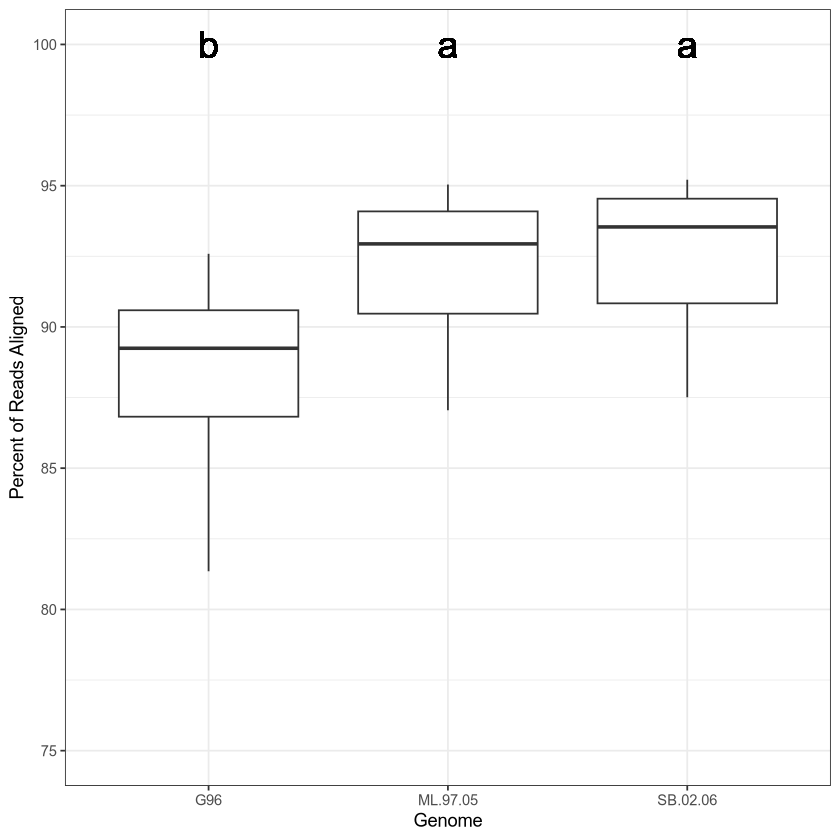

In [17]:
## plot alignment for each strain
alignment_box <- alignment_groups %>%
    ggplot(aes(x = genome, y = percent_aligned)) +
        geom_boxplot(outlier.shape = NA) +
        geom_text(aes(label = group, y = 100), size = 8) +
        labs(x = "Genome", y = "Percent of Reads Aligned") +
        ylim(75, 100) +
        theme_bw()
alignment_box

In [18]:
## save figure
ggsave("figures/sb_alignment/multigenome_alignment_boxplot.png", alignment_box)

Saving 7 x 7 in image
Warning message:
“Removed 21 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


In [19]:
## load in metadata
metadata <- read_csv("input/YABLab_Drosophila_stocks.csv")
head(metadata)

Rows: 294 Columns: 21
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): species_group, Species, strain_ID, strain_type, Genotype, label, s...
dbl  (5): year, latitude, longitude, water_distance_mi, riparian_year

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


species_group,Species,strain_ID,strain_type,Genotype,label,year,slot,saved_on_side,locality,⋯,state,Country,latitude,longitude,Sequencing,Wetland,water_distance_mi,water_source,riparian,riparian_year
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>
virilis,D. americana,15010-0951.00,wild-type,wt,Dame\wild-type,NA,A1-1,NA,"Anderson, Indiana.",⋯,IN,USA,NA,NA,BernardKim_nanopore,NA,NA,NA,NA,NA
virilis,D. americana,15010-0951.01,wild-type,wt,Dame\wild-type,1947,A1-2,NA,"Poplar, Montana.",⋯,MT,USA,NA,NA,NA,NA,NA,NA,NA,NA
virilis,D. americana,15010-0951.02,wild-type,wt,Dame\wild-type,1947,A1-3,NA,"Chinook, Montana.",⋯,MT,USA,NA,NA,NA,NA,NA,NA,NA,NA
virilis,D. americana,15010-0951.03,wild-type,wt,Dame\wild-type,1948,A1-4,NA,"Millersburg, Pennsylvania.",⋯,PA,USA,NA,NA,NA,NA,NA,NA,NA,NA
virilis,D. americana,15010-0951.04,wild-type,wt,Dame\wild-type,1948,A1-5,NA,"Keelers Bay, Lake Champlain, Vermont",⋯,VT,USA,NA,NA,NA,NA,NA,NA,NA,NA
virilis,D. americana,15010-0951.05,wild-type,wt,Dame\wild-type,1948,A2-1,NA,"Jackson, Michigan.",⋯,MI,USA,NA,NA,NA,NA,NA,NA,NA,NA


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


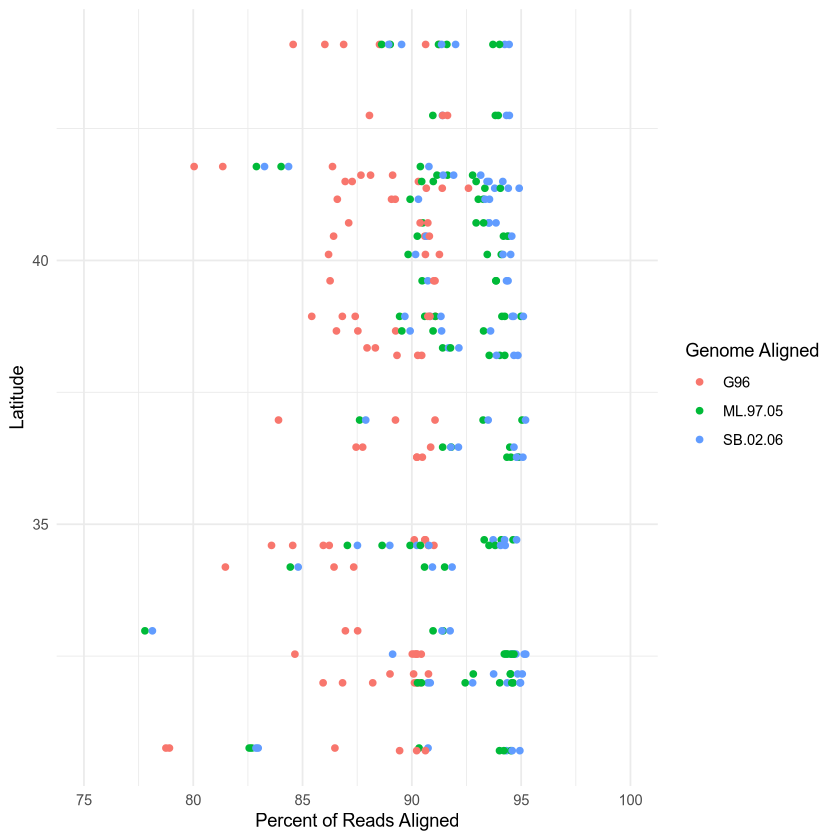

In [20]:
## get latitude for each population
local_lat <- metadata %>%
    select(strain_ID, latitude) %>%
    separate_wider_delim(strain_ID, delim = ".", names = c("locality", "female", "number"), too_few = "align_start", too_many = "drop") %>%
    filter(locality %in% alignment$locality) %>%
    select(locality, latitude) %>%
    na.omit() %>%
    unique()

## combine files
lat_alignment <- alignment %>%
    left_join(local_lat, by = "locality")

lat_plot <- lat_alignment %>%
    na.omit() %>%
    ggplot(aes(x = percent_aligned, y = latitude, color = genome)) +
        geom_point() +
        xlim(75, 100) +
        labs(x = "Percent of Reads Aligned", y = "Latitude", color = "Genome Aligned") +
        theme_minimal()
lat_plot

In [21]:
## save figure
ggsave("figures/sb_alignment/multigenome_alignment_latitude.png", lat_plot)

Saving 7 x 7 in image


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


In [22]:
## determine if there is a significant correlation between latitude and genome
df_g96 <- lat_alignment %>%
    filter(genome == "G96")
cor.test(df_g96$latitude, df_g96$percent_aligned)

df_sb <- lat_alignment %>%
    filter(genome == "SB.02.06")
cor.test(df_sb$latitude, df_sb$percent_aligned)

df_ml <- lat_alignment %>%
    filter(genome == "ML.97.05")
cor.test(df_ml$latitude, df_ml$percent_aligned)


	Pearson's product-moment correlation

data:  df_g96$latitude and df_g96$percent_aligned
t = 1.2794, df = 93, p-value = 0.2039
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.07193273  0.32445973
sample estimates:
     cor 
0.131517 



	Pearson's product-moment correlation

data:  df_sb$latitude and df_sb$percent_aligned
t = 0.55185, df = 93, p-value = 0.5824
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.1460947  0.2557290
sample estimates:
       cor 
0.05713049 



	Pearson's product-moment correlation

data:  df_ml$latitude and df_ml$percent_aligned
t = 0.098423, df = 91, p-value = 0.9218
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.1937986  0.2135764
sample estimates:
       cor 
0.01031696 


In [23]:
## find the genome with the highest alignment for each sample
max_align <- alignment %>%
    select(strain, replicate, genome, percent_aligned) %>%
    mutate(sample = paste(strain, replicate, sep = "_")) %>%
    group_by(sample) %>%
    summarize(genome = genome[which.max(percent_aligned)])

In [24]:
unique(max_align$genome)

[1] "SB.02.06"

## Investigate Expression

In [25]:
## load in gene expression data frames
# counts_g96 <- read_tsv("../workflow/rna/multigenome/results/abundances/G96/stringtie_gene_matrix.txt")
# counts_ml <- read_tsv("../workflow/rna/multigenome/results/abundances/ML.97.05/stringtie_gene_counts_matrix.txt")
counts_sb <- read_tsv("../workflow/rna/multigenome/results/abundances/SB.02.06/stringtie_gene_matrix.txt")

## clean up column names
# samples_g96 <- colnames(counts_g96) %>%
#     as.data.frame() %>%
#     rename(name = 1) %>%
#     mutate(name = str_remove_all(name, "/home/clavery/projects/dagrp/dagrp_zwa/workflow/rna_alt/results/HISAT-2/G96/"),
#            name = str_remove_all(name, ".csorted.hisat2.bam")) %>%
#     filter(grepl("G96", name)) %>%
#     mutate(name = str_remove_all(name, "_G96")) %>%
#     pull("name")
# colnames_g96 <- c("gene", samples_g96)
# colnames(counts_g96) <- colnames_g96

# samples_ml <- colnames(counts_ml) %>%
#     as.data.frame() %>%
#     rename(name = 1) %>%
#     mutate(name = str_remove_all(name, "/home/clavery/projects/dagrp/dagrp_zwa/workflow/rna_alt/results/HISAT-2/SB.02.06/"),
#            name = str_remove_all(name, ".csorted.hisat2.bam")) %>%
#     filter(grepl("ML", name)) %>%
#     mutate(name = str_remove_all(name, "_ML.97.05")) %>%
#     pull("name")
# colnames_ml <- c("gene", samples_ml)
# colnames(counts_ml) <- colnames_ml

names_sb <- colnames(counts_sb) %>%
    as.data.frame()
colnames(names_sb) <- "name"

samples_sb <- names_sb %>%
    mutate(name = str_remove_all(name, "/home/clavery/projects/dagrp/dagrp_zwa/workflow/rna_alt/results/HISAT-2/SB.02.06/"),
           name = str_remove_all(name, ".csorted.hisat2.bam")) %>%
    filter(grepl("SB", name)) %>%
    mutate(name = str_remove_all(name, "_SB.02.06")) %>%
    pull("name")
colnames_sb <- c("gene", samples_sb)
colnames(counts_sb) <- colnames_sb

head(counts_sb)

Rows: 14748 Columns: 102
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr   (1): Geneid
dbl (101): /home/clavery/projects/dagrp/dagrp_zwa/workflow/rna_alt/results/H...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


gene,BB_05_18_rep1,BB_05_18_rep2,BB_05_18_rep3,BU_06_06_rep1,BU_06_06_rep2,BU_06_06_rep3,BU_06_10_rep1,BU_06_10_rep2,BU_06_10_rep3,⋯,SV_07_02_rep3,WR_06_22_rep1,WR_06_22_rep2,WR_06_22_rep3,WR_06_44_rep1,WR_06_44_rep2,WR_06_44_rep3,WS_07_06_rep1,WS_07_06_rep2,WS_07_06_rep3
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
cdi,16402,9827,7866,16153,6773,7140,5824,6780,7562,⋯,7083,10785,5203,5899,8669,9854,5380,8793,8566,9123
mRpL55,230,379,270,353,306,352,227,507,276,⋯,281,335,299,191,376,727,264,452,486,419
ATPsynD,3382,3727,2784,4346,3933,2657,3887,3513,1892,⋯,3623,4833,3165,2267,3243,4950,2318,5353,3990,4339
sav,1991,1749,995,1656,956,728,845,973,871,⋯,1024,1501,808,537,1212,1170,523,1906,1360,1378
Ctns,500,561,516,549,848,371,801,578,625,⋯,322,463,370,431,524,277,194,475,801,685
p53,367,423,219,584,498,280,464,364,384,⋯,244,373,270,285,440,396,304,375,474,399


In [26]:
# ## pivot gene expression data to be long
# counts_g96_long <- counts_g96 %>%
#     pivot_longer(!gene, names_to = "sample", values_to = "G96")
# counts_sb_long <- counts_sb %>%
#     pivot_longer(!gene, names_to = "sample", values_to = "SB.02.06")
# counts_ml_long <- counts_ml %>%
#     pivot_longer(!gene, names_to = "sample", values_to = "ML.97.05")

# ## join reads together
# raw_counts <- counts_g96_long %>%
#     full_join(counts_sb_long, by = c("gene", "sample")) %>%
#     full_join(counts_ml_long, by = c("gene", "sample")) %>%
#     pivot_longer(c(G96, SB.02.06, ML.97.05), names_to = "reference", values_to = "count") %>%
#     left_join(max_align, by = "sample") %>%
#     filter(reference == genome) %>%
#     select(-c(reference, genome)) %>%
#     pivot_wider(values_from = count, names_from = sample) %>%
#     column_to_rownames("gene")
# head(raw_counts)

In [27]:
raw_counts <- counts_sb %>%
    column_to_rownames("gene")

## convert to counts per million and remove reads with fewer than 5 reads per 3 samples
cpm_cm <- cpm(raw_counts)
thresh_cm <- cpm_cm > 5
keep_cm <- rowSums(thresh_cm) >= 3
reads <- raw_counts[keep_cm,]

head(reads)

,BB_05_18_rep1,BB_05_18_rep2,BB_05_18_rep3,BU_06_06_rep1,BU_06_06_rep2,BU_06_06_rep3,BU_06_10_rep1,BU_06_10_rep2,BU_06_10_rep3,CB_05_22_rep1,⋯,SV_07_02_rep3,WR_06_22_rep1,WR_06_22_rep2,WR_06_22_rep3,WR_06_44_rep1,WR_06_44_rep2,WR_06_44_rep3,WS_07_06_rep1,WS_07_06_rep2,WS_07_06_rep3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
cdi,16402,9827,7866,16153,6773,7140,5824,6780,7562,12893,⋯,7083,10785,5203,5899,8669,9854,5380,8793,8566,9123
mRpL55,230,379,270,353,306,352,227,507,276,442,⋯,281,335,299,191,376,727,264,452,486,419
ATPsynD,3382,3727,2784,4346,3933,2657,3887,3513,1892,5427,⋯,3623,4833,3165,2267,3243,4950,2318,5353,3990,4339
sav,1991,1749,995,1656,956,728,845,973,871,1926,⋯,1024,1501,808,537,1212,1170,523,1906,1360,1378
Ctns,500,561,516,549,848,371,801,578,625,754,⋯,322,463,370,431,524,277,194,475,801,685
p53,367,423,219,584,498,280,464,364,384,511,⋯,244,373,270,285,440,396,304,375,474,399


In [28]:
## create sample information data frame
reads_names <- colnames(reads) %>%
    as.data.frame()
colnames(reads_names) <- "sample"

sample_info <- reads_names %>%
    separate_wider_delim(sample, delim = "_", names = c("locality", "female", "number", "replicate"), too_few = "align_start", cols_remove = FALSE) %>%
    mutate(strain = case_when(is.na(replicate) ~ paste(locality, female, sep = "_"),
                              TRUE ~ paste(locality, female, number, sep = "_")),
           replicate = case_when(is.na(replicate) ~ number,
                                 TRUE ~ replicate))

## create design matrix 
groups <- sample_info$strain
design <- model.matrix(~0 + groups)
rownames(design) <- colnames(reads)
colnames(design) <- str_replace(colnames(design), "groups", "")

head(design)

,BB_05_18,BU_06_06,BU_06_10,CB_05_22,CD_97_5,CF_05_14,CI_05_20,DA_06_36,DI_10_02,DmonCol_13,⋯,PG_05_04,PG_06_36,PM_99_18,RB_10_16,SB_02_06,SC_07_06,SV_07_02,WR_06_22,WR_06_44,WS_07_06
BB_05_18_rep1,1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
BB_05_18_rep2,1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
BB_05_18_rep3,1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
BU_06_06_rep1,0,1,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
BU_06_06_rep2,0,1,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
BU_06_06_rep3,0,1,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [29]:
## get number of covariables (number of strains)
covariant <- length(unique(sample_info$strain))
covariant

[1] 34

In [30]:
# ## create DGE object
# set <- newSeqExpressionSet(as.matrix(reads), phenoData = data.frame(groups, row.names = colnames(reads)))
# set <- betweenLaneNormalization(set, which="upper")

# y <- DGEList(counts=counts(set), group=groups)
# y <- calcNormFactors(y, method="upperquartile")
# y <- estimateDisp(y, design, robust = T)
# fit <- glmQLFit(y, design, dispersion = y$tagwise.dispersion, robust = T)
# res <- residuals(fit, type="deviance")

# ## create DGElist object with new design
# dgeList <- DGEList(counts = reads, group = groups)
# dgeList <- calcNormFactors(dgeList)
# dgeList <- estimateDisp(dgeList, design)
# dgeList_fit <- glmQLFit(dgeList, design, robust = TRUE)
# summary(dgeList$tagwise.dispersion)

In [31]:
# options(repr.plot.width = 15, repr.plot.height = 10)

# # Use the function before each plot
# par(mfrow = c(2, 3))

# ## QL dispersion plot
# plotQLDisp(dgeList_fit, col.raw = "white", cex = 0.8, col.trend = "yellow", )

# ## Biological coefficient of variation
# plotBCV(dgeList, col.tagwise = "white", cex = 0.8)

# ## Mean-variance trend
# voom <- voom(dgeList, design_2, plot = TRUE)

# ## Goodness of fit/Q-Q plot
# g.v <- gof(dgeList_fit, plot = FALSE, pcutoff = 0.05, adjust = "holm")
# z.v <- zscoreGamma(g.v$gof.statistics,shape=g.v$df/2,scale=2)
# qqnorm(z.v); qqline(z.v, col = 4,lwd=1,lty=1)

# ## normalized CPM check
# boxplot(voom$E, xlab="", ylab="Log2 counts per million",las=2,main="Voom transformed logCPM")
# abline(h=median(voom$E),col="blue")

In [32]:
## create DGE object
set <- newSeqExpressionSet(as.matrix(reads), phenoData = data.frame(groups, row.names = colnames(reads)))
set <- betweenLaneNormalization(set, which="upper")

y <- DGEList(counts=counts(set), group=groups)
y <- calcNormFactors(y, method="upperquartile")
y <- estimateDisp(y, design, robust = T)
fit <- glmQLFit(y, design, dispersion = y$tagwise.dispersion, robust = T)
res <- residuals(fit, type="deviance")

## normalize with RUVr
batch_ruv_res <- RUVr(set, rownames(reads), k=covariant,res)

## create new design matrix with RUVr coefficients
design_2 <- model.matrix(~ 0 + groups, data = pData(batch_ruv_res))
colnames(design_2) <- gsub("groups", "", colnames(design_2))

## create DGElist object with new design
dgeList <- DGEList(counts = reads, group = groups)
dgeList <- calcNormFactors(dgeList)
dgeList <- estimateDisp(dgeList, design_2)
dgeList_fit <- glmQLFit(dgeList, design_2, robust = TRUE)
summary(dgeList$tagwise.dispersion)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.005531 0.025274 0.044817 0.146252 0.105628 8.835269 

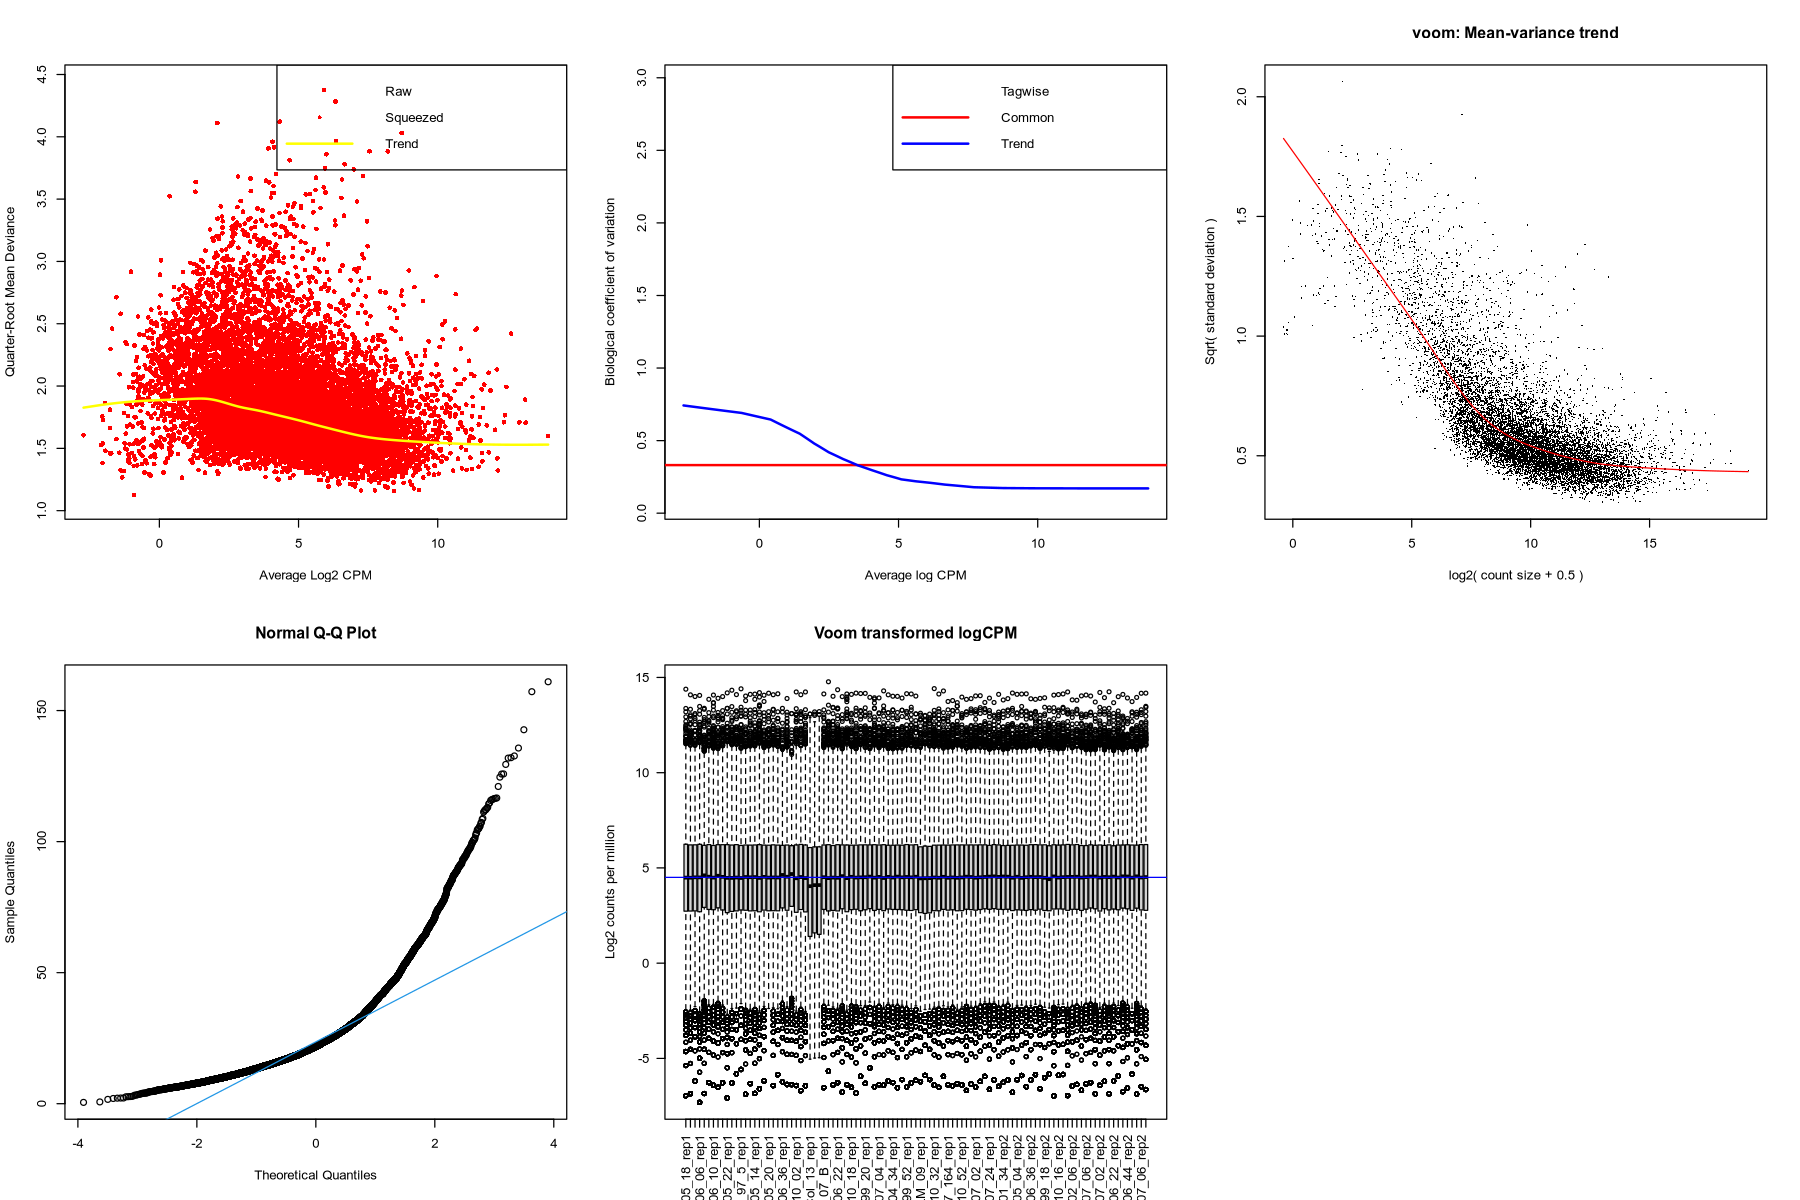

In [33]:
options(repr.plot.width = 15, repr.plot.height = 10)

# Use the function before each plot
par(mfrow = c(2, 3))

## QL dispersion plot
plotQLDisp(dgeList_fit, col.raw = "white", cex = 0.8, col.trend = "yellow", )

## Biological coefficient of variation
plotBCV(dgeList, col.tagwise = "white", cex = 0.8)

## Mean-variance trend
voom <- voom(dgeList, design_2, plot = TRUE)

## Goodness of fit/Q-Q plot
g.v <- gof(dgeList_fit, plot = FALSE, pcutoff = 0.05, adjust = "holm")
z.v <- zscoreGamma(g.v$gof.statistics,shape=g.v$df/2,scale=2)
qqnorm(z.v); qqline(z.v, col = 4,lwd=1,lty=1)

## normalized CPM check
boxplot(voom$E, xlab="", ylab="Log2 counts per million",las=2,main="Voom transformed logCPM")
abline(h=median(voom$E),col="blue")

In [34]:
## normalize with new design
y <- estimateDisp(y, design_2, robust = T)
fit <- glmQLFit(y, design_2, dispersion = y$tagwise.dispersion, robust = T)
res <- residuals(fit, type="deviance")

## normalize with RUVr
batch_ruv_res <- RUVr(set, rownames(reads), k=covariant,res)
RUVrNormalizedCounts <- normCounts(object = batch_ruv_res)
rownames(RUVrNormalizedCounts) <- rownames(reads)

## reformat normalized reads for saving
normalized_reads <- RUVrNormalizedCounts %>%
    as.data.frame() %>%
    rownames_to_column("gene")
head(normalized_reads)

,gene,BB_05_18_rep1,BB_05_18_rep2,BB_05_18_rep3,BU_06_06_rep1,BU_06_06_rep2,BU_06_06_rep3,BU_06_10_rep1,BU_06_10_rep2,BU_06_10_rep3,⋯,SV_07_02_rep3,WR_06_22_rep1,WR_06_22_rep2,WR_06_22_rep3,WR_06_44_rep1,WR_06_44_rep2,WR_06_44_rep3,WS_07_06_rep1,WS_07_06_rep2,WS_07_06_rep3
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,cdi,8583,8785,8738,6625,6595,6659,6446,6552,6328,⋯,7384,7539,7085,7024,7990,7339,7546,7000,7394,7385
2,mRpL55,214,228,256,254,222,261,285,311,336,⋯,306,276,294,267,405,427,405,354,346,381
3,ATPsynD,2488,2542,2837,2759,2516,2599,3015,2770,2933,⋯,3673,3335,3295,3564,3137,3587,3170,3656,3471,3797
4,sav,1203,1218,1218,775,741,772,839,806,971,⋯,1023,887,924,895,870,898,926,1261,1240,1205
5,Ctns,414,400,448,417,427,387,688,679,602,⋯,308,450,395,447,278,347,293,503,568,469
6,p53,265,251,266,324,311,313,393,389,397,⋯,243,362,277,310,385,336,391,325,366,306


In [35]:
write_tsv(normalized_reads, "intermediate/sb_dagrp_normalized_reads.tsv")

In [36]:
## pick the top 50% most variable genes
variance_cutoff <- 0.5
variance_per_genes <- apply(RUVrNormalizedCounts, 1, mad)
min_variance <- quantile(variance_per_genes, c(variance_cutoff))
variance_filtered_data <- RUVrNormalizedCounts[variance_per_genes > min_variance, ]

In [37]:
## Plot sample correlation
data <- log2(variance_filtered_data + 1)
data <- as.matrix(data)
sample_cor <- cor(data, method = "pearson", use = "pairwise.complete.obs")

sampleColLabeling <- sample_info
rownames(sampleColLabeling) <- sampleColLabeling$sample
sampleColLabeling <- subset(sampleColLabeling, select = c("sample", "strain"))

# Prepare the annotations
annotations <- HeatmapAnnotation(
    df = sampleColLabeling
)

## create heat map and save to results

png("figures/sb_reads_heatmap.png", width = 20, height = 14, units = "in", res = 1200)

draw(Heatmap(sample_cor, 
              name = "Correlation", # Name of the heatmap, appears as the title
              show_row_names = TRUE,
              show_column_names = TRUE,
              top_annotation = annotations,
            #    = annotations,  # Assuming you want row annotations as well
              # column_title = "Sample Title", # Title for the columns
              # row_title = "Row Title", # Title for the rows
              column_title_gp = gpar(col = "white"), # Column title text properties
              column_dend_gp = gpar(col = "white"),
              row_dend_gp = gpar(col = "white"),
              row_title_gp = gpar(col = "white"), # Row title text properties
              column_names_gp = gpar(col = "white", fontface = "bold"), # Column label text properties
              row_names_gp = gpar(col = "white", fontface = "bold"), # Row label text properties
              heatmap_legend_param = list(title = "Correlation",
                                    title_gp = gpar(col = "white"),
                                    labels_gp = gpar(col = "white")), # Legend text properties
              # col = viridis(n = 100, option = "inferno")  # Using the 'inferno' color scale from viridis
             ),
    background = "#1E1E1E")

dev.off()

Warning message:
“Setting row names on a tibble is deprecated.”


pdf 
  2

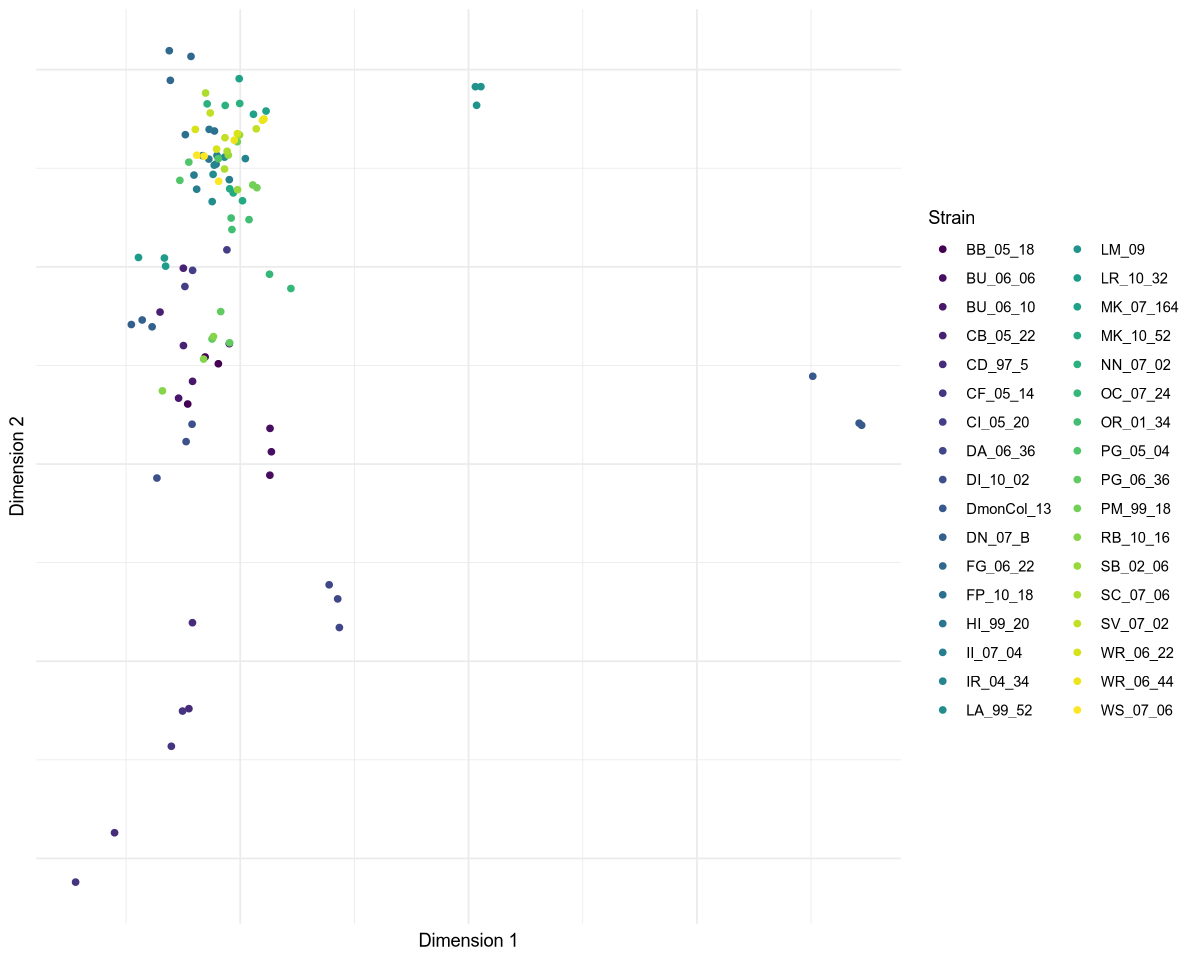

In [38]:
## increase reads by 1, to account for genes with 0 reads
variance_reads_mx <- variance_filtered_data + 1

## create MDS object
mds_coords <- plotMDS(variance_reads_mx + 1, plot = F)
mdsObj <- data.frame(dim1 = mds_coords$x, dim2 = mds_coords$y)
mdsObj$sample <- sample_info$sample

mdsObj <- merge(mdsObj, sample_info, by.x = "sample")

## plot MDS
options(repr.plot.width = 10, repr.plot.height = 8)
MDS <- mdsObj %>%
    ggplot(aes(x = dim1, y = dim2, color = strain)) +
    geom_point() +
    labs(x = "Dimension 1", y = "Dimension 2", color = "Strain") +
    scale_color_viridis(discrete = TRUE) +
    theme_minimal() +
    theme(axis.text = element_blank())
MDS

In [39]:
## save MDS
ggsave("figures/sb_alignment/sb_reads_mds.png", MDS)

Saving 7 x 7 in image


Warning message:
“ggrepel: 52 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


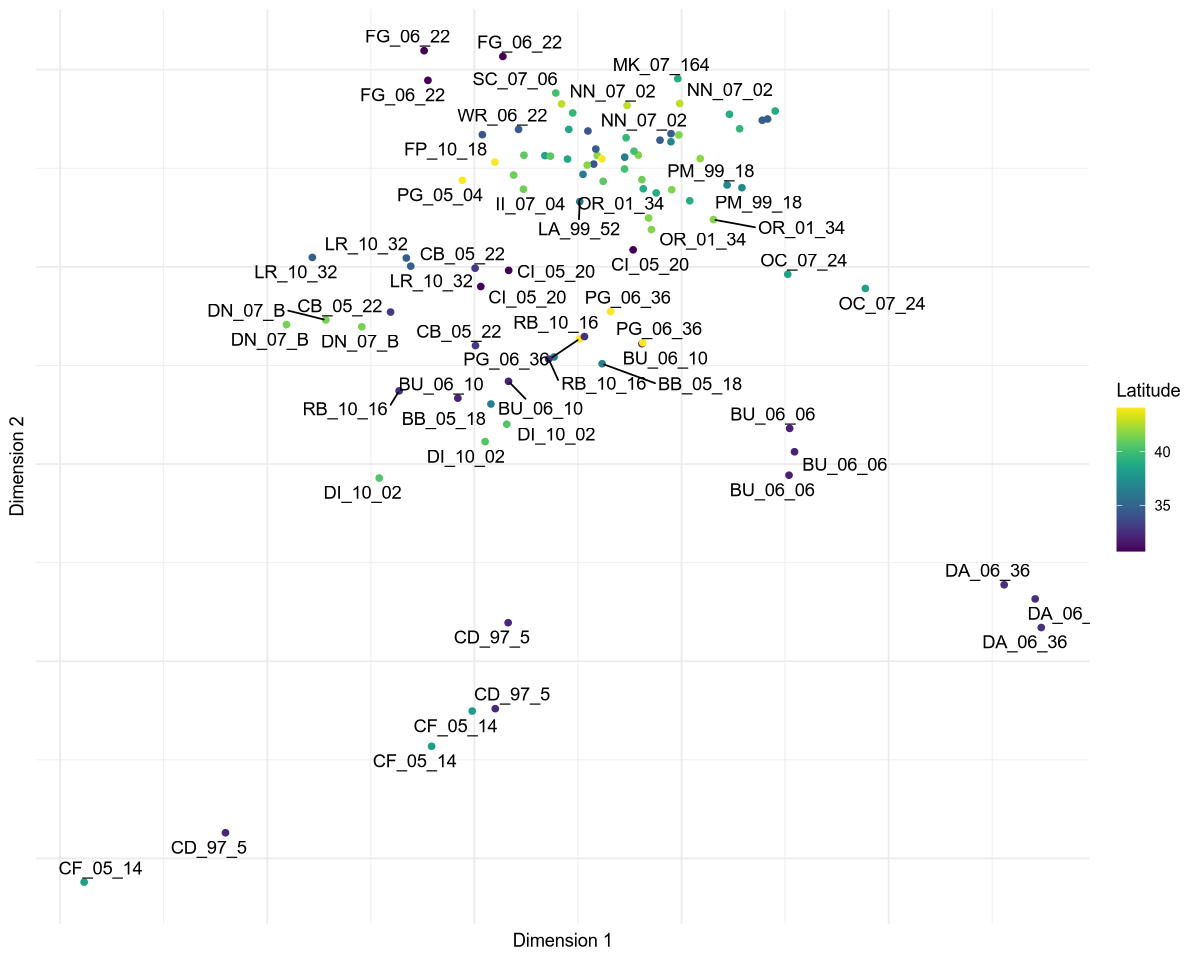

In [40]:
## plot MDS to see correlation wiht latitude
mds_lat <- mdsObj %>%
    left_join(local_lat, by = "locality") %>%
    na.omit()

mds_lat_plot <- mds_lat %>%
    unique() %>%
    ggplot(aes(x = dim1, y = dim2, label = strain)) +
        geom_point(aes(color = latitude)) +
        geom_text_repel(xlim = c(NA, Inf), ylim = c(-Inf, Inf)) +
        labs(x = "Dimension 1", y = "Dimension 2", color = "Latitude") +
        scale_color_viridis() +
        theme_minimal() +
        theme(axis.text = element_blank())
mds_lat_plot

In [41]:
## save MDS
ggsave("figures/sb_alignment/sb_reads_mds_lat.png", mds_lat_plot)

Saving 7 x 7 in image


Warning message:
“ggrepel: 52 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


In [42]:
## load in GTF
gtf_raw <- read_tsv("/home/yahmed-labshare/data/genomes/virilis_group/americana/SB.02.06/Muller/Polished/gffcompare/sb.02.06.combined.gtf", col_names = FALSE)

## clean up GTF for downstream use
colnames(gtf_raw) <- c("chromosome", "source", "feature", "start", "end", "score", "strand", "frame", "attribute")
gtf <- gtf_raw %>%
    filter(feature == "transcript") %>%
    mutate(attribute = str_remove_all(attribute, "\""),
           attribute = str_remove_all(attribute, " "),
           chromosome = str_remove_all(chromosome, "_RagTag")) %>%
    separate_wider_delim(attribute, delim = ";", names = c("transcript", "gene_id", "gene", "extra"), too_many = "drop") %>%
    mutate(transcript = str_remove_all(transcript, "transcript_id"),
           gene_id = str_remove_all(gene_id, "gene_id"),
           gene = str_remove_all(gene, "oId"),
           gene = str_remove_all(gene, "gene_name"),
           extra = str_remove_all(chromosome, "tss_id"))
head(gtf)

Rows: 283442 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (7): X1, X2, X3, X6, X7, X8, X9
dbl (2): X4, X5

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


chromosome,source,feature,start,end,score,strand,frame,transcript,gene_id,gene,extra
<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Chr_2,AUGUSTUS,transcript,4872,5240,.,+,.,gffcompare/sb.02.06/sb.02.06_00000001,XLOC_000001,g1.t1,Chr_2
Chr_2,AUGUSTUS,transcript,5363,5692,.,+,.,gffcompare/sb.02.06/sb.02.06_00000002,XLOC_000002,g2.t1,Chr_2
Chr_2,AUGUSTUS,transcript,7348,7590,.,+,.,gffcompare/sb.02.06/sb.02.06_00000003,XLOC_000003,g3.t1,Chr_2
Chr_2,AUGUSTUS,transcript,11257,12588,.,+,.,gffcompare/sb.02.06/sb.02.06_00000004,XLOC_000004,g4.t1,Chr_2
Chr_2,AUGUSTUS,transcript,12642,13982,.,+,.,gffcompare/sb.02.06/sb.02.06_00000005,XLOC_000005,g5.t1,Chr_2
Chr_2,AUGUSTUS,transcript,17648,20284,.,+,.,gffcompare/sb.02.06/sb.02.06_00000006,XLOC_000006,g6.t1,Chr_2


In [43]:
## filter for only genes and their chromosome
gtf_genes <- gtf %>%
    filter(feature == "transcript" & grepl("Chr", chromosome)) %>%
    select(chromosome, gene) %>%
    unique()

# ## create empty dataframe to populate
# mds_obj <- mds_lat %>%
#     pivot_longer(c(dim1, dim2), names_to = "dimension", values_to = "whole_transcriptome")

# ## create mds for each chromosome
# for (i in unique(gtf_genes$chromosome)) {
    
#     ## get the list of genes on the relevent chromosome
#     chr_genes <- gtf_genes %>%
#         filter(chromosome == i) %>%
#         pull("gene") %>%
#         unique()
    
#     ## filter read data for only chromosome genes
#     chr_reads_mx <- variance_reads_mx[rownames(variance_reads_mx) %in% chr_genes, ]
    
#     ## plot chromosome specific MDS
#     mds_coords <- plotMDS(chr_reads_mx + 1, plot = F)
#     mdsObj <- data.frame(dim1 = mds_coords$x, dim2 = mds_coords$y)
#     mdsObj$sample <- sample_info$sample

#     ## add chromosome information to data frame
#     mdsObj <- mdsObj %>%
#         pivot_longer(!sample, names_to = "dimension", values_to = i)
#     mds_obj <- mds_obj %>%
#         full_join(mdsObj, by = c("sample", "dimension"))
# }

# ## remove initial column and transform dimension and chromosome
# mds_obj <- mds_obj %>%
#     select(-whole_transcriptome) %>%
#     pivot_longer(contains("Chr"), names_to = "chromosome", values_to = "values") %>%
#     pivot_wider(names_from = dimension, values_from = values) %>%
#     na.omit()

# write_tsv(mds_obj, "intermediate/chromosome_mds.tsv")

Rows: 570 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (7): sample, locality, female, number, replicate, strain, chromosome
dbl (3): latitude, dim1, dim2

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“ggrepel: 90 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 80 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 80 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 92 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 82 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 82 unlabeled data points (too many overlaps). Consider increa

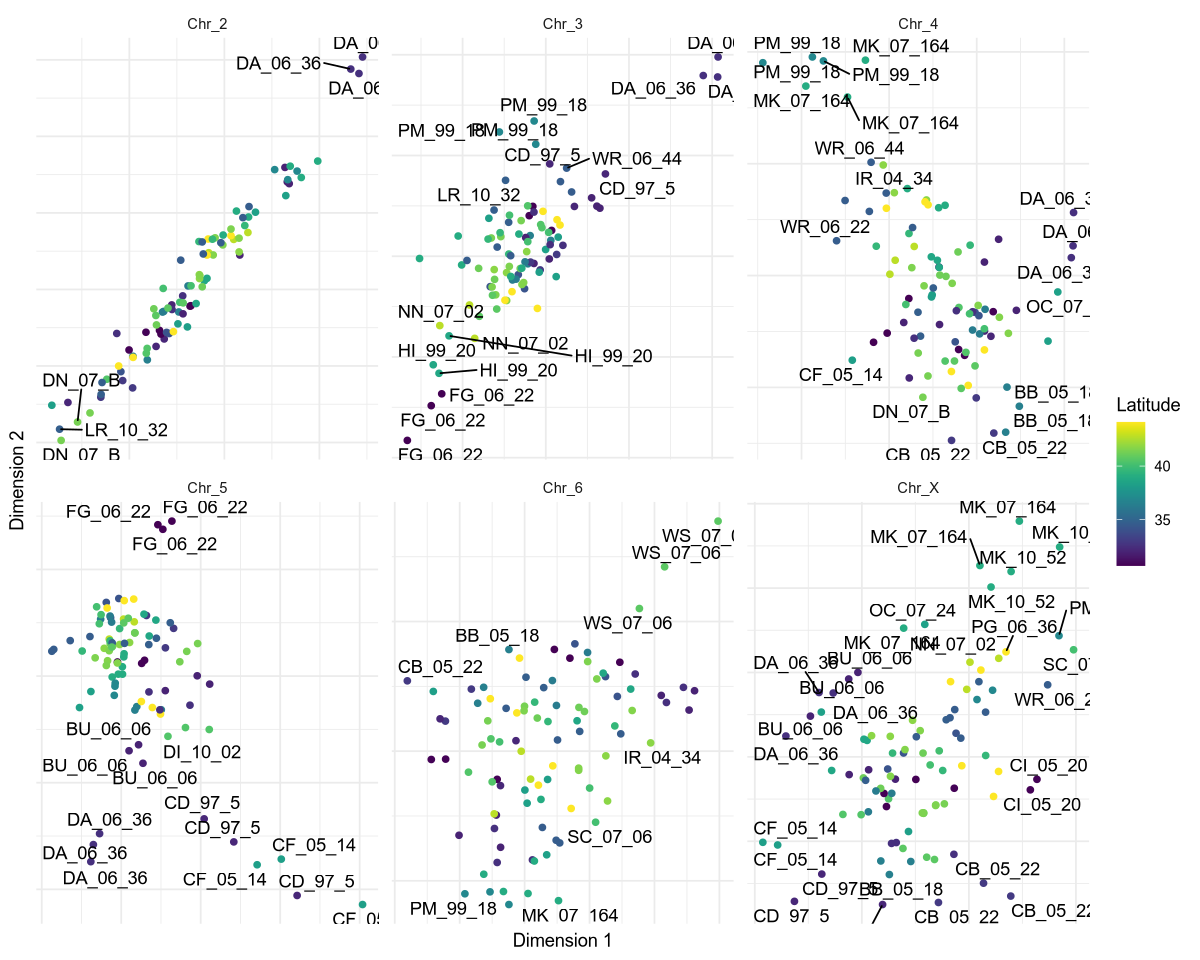

In [44]:
## load in MDS plot
mds_obj <- read_tsv("intermediate/chromosome_mds.tsv")

## plot MDS by chromosome
mds_chr_plot <- mds_obj %>%
    unique() %>%
    ggplot(aes(x = dim1, y = dim2, label = strain)) +
        geom_point(aes(color = latitude)) +
        geom_text_repel(xlim = c(NA, Inf), ylim = c(-Inf, Inf)) +
        labs(x = "Dimension 1", y = "Dimension 2", color = "Latitude") +
        scale_color_viridis() +
        theme_minimal() +
        theme(axis.text = element_blank(),
              panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA)) +
        facet_wrap(~chromosome, scales = "free")
mds_chr_plot

In [45]:
## save MDS
ggsave("figures/sb_alignment/sb_reads_chr_mds_lat+labels.png", mds_chr_plot, width = 10, height = 8)

Warning message:
“ggrepel: 89 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 79 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 78 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 87 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 76 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 70 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


In [46]:
## combine the latitude and expression data
chr_expression_lat <- variance_filtered_data %>%
    scale() %>%
    as.data.frame() %>%
    rownames_to_column("gene") %>%
    pivot_longer(!gene, names_to = "sample", values_to = "expression") %>%
    left_join(gtf_genes, by = "gene", relationship = "many-to-many") %>%
    separate_wider_delim(sample, delim = "_", names = c("locality", "female", "strain", "replicate"), too_few = "align_start", cols_remove = FALSE) %>%
    inner_join(local_lat, by = "locality") %>%
    filter(!is.na(chromosome))

# chr_expression_lat_box <- chr_expression_lat %>%
#     mutate(chromosome = str_replace(chromosome, "Chr_", "Chromosome ")) %>%
#     ggplot(aes(x = fct_reorder(locality, latitude), y = log2(expression), color = latitude)) +
#         geom_boxplot(outlier.shape = NA) +
#         labs(x = "Locality", y = "log2(Normalized Gene Expression)", color = "Latitude") +
#         scale_color_viridis() +
#         theme_minimal() +
#         theme(panel.background = element_rect(fill = "white", color = NA),
#               plot.background = element_rect(fill = "white", color = NA),
#               legend.position = "top") +
#         facet_grid(rows = vars(chromosome), scales = "free_x")
# chr_expression_lat_box

In [47]:
# ## save plot
# ggsave("figures/sb_alignment/sb_reads_boxexpression_chr.png", chr_expression_lat_box, width = 10, height = 12)

### Determine if there is a difference in expression based on fusion status

In [48]:
## load in fusion data
fusion <- read_tsv("input/strain_fusion.tsv") %>%
    janitor::clean_names() %>%
    mutate(strain = str_replace_all(strain, "\\.", "_"))

head(fusion)

Rows: 23 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): Strain, Status

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


strain,status
<chr>,<chr>
BB_05_18,Fused
FG_06_22,Unfused
FP_10_18,Unfused
HI_99_20,Fused
II_07_04,Segregating
IR_04_34,Fused


In [49]:
## create a sample info dataframe with fusion status
sample_info <- colnames(normalized_reads) %>%
    as.data.frame() %>%
    rename(sample = 1) %>%
    filter(grepl("_", sample)) %>%
    separate_wider_delim(sample, delim = "_", names = c("locality", "female", "number", "replicate"), too_few = "align_start", cols_remove = FALSE) %>%
    mutate(replicate = case_when(is.na(replicate) ~ number,
                                 TRUE ~ replicate),
           number = case_when(replicate == number ~ NA,
                              TRUE ~ number),
           strain = case_when(is.na(number) ~ paste(locality, female, sep = "_"),
                              TRUE ~ paste(locality, female, number, sep = "_"))) %>%
    left_join(local_lat, by = "locality") %>%
    left_join(fusion, by = "strain") %>%
    select(sample, strain, status, latitude, locality)
head(sample_info)

sample,strain,status,latitude,locality
<chr>,<chr>,<chr>,<dbl>,<chr>
BB_05_18_rep1,BB_05_18,Fused,36.46119,BB
BB_05_18_rep2,BB_05_18,Fused,36.46119,BB
BB_05_18_rep3,BB_05_18,Fused,36.46119,BB
BU_06_06_rep1,BU_06_06,NA,31.99426,BU
BU_06_06_rep2,BU_06_06,NA,31.99426,BU
BU_06_06_rep3,BU_06_06,NA,31.99426,BU


In [50]:
## calculate logfc based on fusion status

## create empty logfc table to add the future log fold change data to
logfc_fusion <- data.frame(gene = normalized_reads$gene) %>%
    rownames_to_column("number")

## truncate all of the data to only include populations with fusion information
trunc_sample_info <- sample_info %>% 
    filter(grepl("fuse", status, ignore.case = TRUE)) %>%
    filter(locality != "SB")
trunc_cm <- normalized_reads %>%
    select(any_of(trunc_sample_info$sample))
trunc_groups <- trunc_sample_info$status
trunc_latitude <- trunc_sample_info$latitude
trunc_design <- model.matrix(~ trunc_groups + trunc_latitude)

## run differential gene expression
trunc_dgeList <- DGEList(counts = trunc_cm, group = trunc_groups)
trunc_dgeList <- calcNormFactors(trunc_dgeList)
trunc_dgeList <- estimateDisp(trunc_dgeList, trunc_design)
trunc_dgeList_fit <- glmQLFit(trunc_dgeList, trunc_design, robust = TRUE)

trunc_dge <- glmTreat(trunc_dgeList_fit, coef = 2)
trunc_dge_tags <- topTags(trunc_dge, n = NULL)

## get logfc and statistical information
logfc_fusion <- trunc_dge_tags$table %>%
    rownames_to_column("number") %>%
    full_join(logfc_fusion, by = "number") %>%
    select(-number) %>%
    select(gene, logFC, PValue, FDR) %>%
    mutate(significance = case_when(PValue < 0.05 & FDR < 0.01 ~ "Significant",
                                    TRUE ~ "Not Significant"))

Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.ob

In [51]:
## count how many significant and unsignificant genes
logfc_fusion %>%
    group_by(significance) %>%
    count()
## excluding SB increased the significant genes from 91 to 157

significance,n
<chr>,<int>
Not Significant,10468
Significant,157


Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


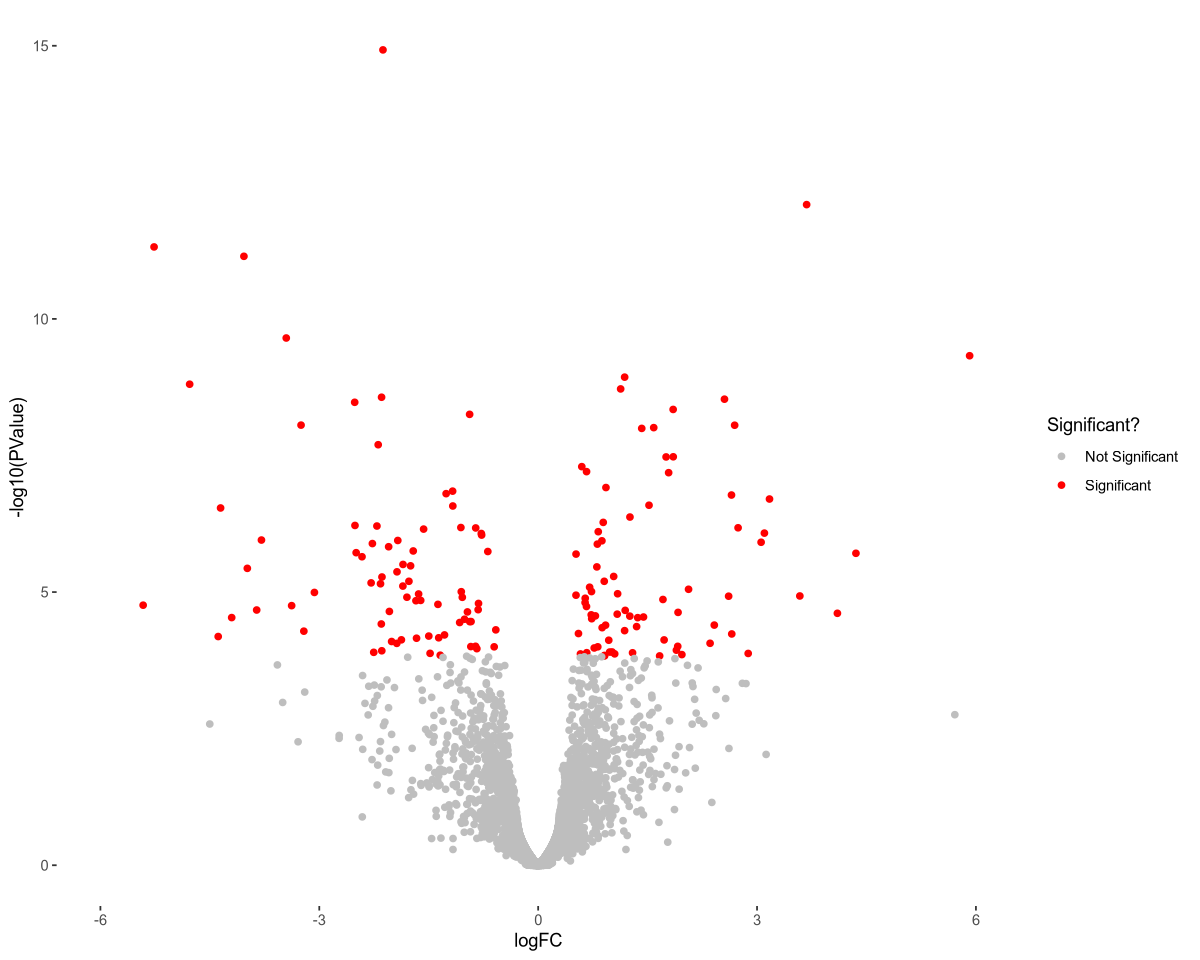

In [52]:
## plot volcano for fusion
fusion_volcano <- logfc_fusion %>%
    ggplot(aes(x = logFC, y = -log10(PValue), color = significance)) +
        geom_point() +
        labs(color = "Significant?") +
        scale_color_manual(values = c("gray", "red")) +
        xlim(-6, 6) +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA))
fusion_volcano

In [53]:
## save plot
ggsave("figures/sb_alignment/fusion_volcano.png", fusion_volcano)

Saving 7 x 7 in image


Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


In [54]:
## add location information to logfc data
logfc_fusion_chr <- gtf_genes %>%
    full_join(logfc_fusion, by = "gene") %>%
    mutate(significance = case_when(is.na(significance) ~ "Not Significant",
                                    TRUE ~ significance)) %>%
    na.omit()

## determine if there is an enrichment for differentially expressed genes on the fourth chromosome
fourth_diff <- logfc_fusion_chr %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, significance) %>%
    count() %>%
    pivot_wider(names_from = significance, values_from = n) %>%
    mutate(across(is.numeric, replace_na, replace = 0)) %>%
    column_to_rownames("fourth")
fisher.test(fourth_diff)$p.value

## determine if there is an enrichment for genes with decreased expression on the fourth chromosome
fourth_low <- logfc_fusion_chr %>%
    mutate(direction = case_when(logFC < 0 & significance == "Significant" ~ "decrease",
                                 TRUE ~ "other")) %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, direction) %>%
    count() %>%
    pivot_wider(names_from = direction, values_from = n) %>%
    mutate(across(is.numeric, replace_na, replace = 0)) %>%
    column_to_rownames("fourth")
fisher.test(fourth_low)$p.value

## determine if there is an enrichment for genes with decreased expression on the fourth chromosome
fourth_low <- logfc_fusion_chr %>%
    mutate(direction = case_when(logFC > 0 & significance == "Significant" ~ "decrease",
                                 TRUE ~ "other")) %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, direction) %>%
    count() %>%
    pivot_wider(names_from = direction, values_from = n) %>%
    mutate(across(is.numeric, replace_na, replace = 0)) %>%
    column_to_rownames("fourth")
fisher.test(fourth_low)$p.value

Warning message:
“There were 2 warnings in `mutate()`.
The first warning was:
ℹ In argument: `across(is.numeric, replace_na, replace = 0)`.
ℹ In group 1: `fourth = "fourth"`.
Caused by warning:
! Use of bare predicate functions was deprecated in tidyselect 1.1.0.
ℹ Please use wrap predicates in `where()` instead.
  # Was:
  data %>% select(is.numeric)

  # Now:
  data %>% select(where(is.numeric))
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.”


[1] 0.3146108

[1] 0.3943453

[1] 0.01047379

In [55]:
logfc_fusion_chr %>%
    mutate(direction = case_when(logFC < 0 & significance == "Significant" ~ "decrease",
                                 TRUE ~ "other")) %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, direction) %>%
    count() %>%
    pivot_wider(names_from = direction, values_from = n)

fourth,decrease,other
<chr>,<int>,<int>
fourth,19,2050
other,59,8132


Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


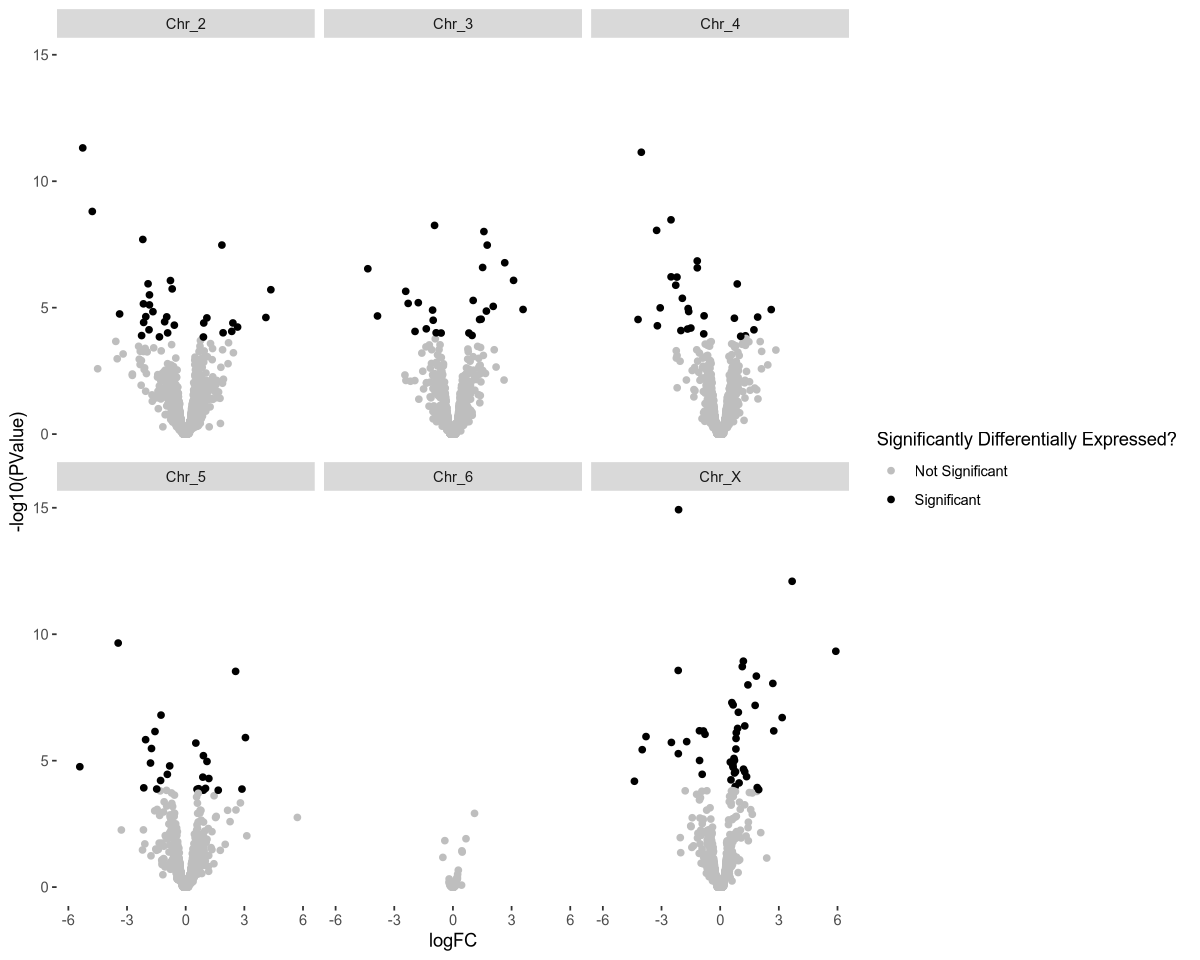

In [58]:
## plot volcano for fusion
fusion_chr_volcano <- logfc_fusion_chr %>%
    mutate(chr = case_when(significance == "Significant" ~ str_replace_all(chromosome, "Chr_", "Chromosome "),
                           TRUE ~ "Not Significant")) %>%
    ggplot(aes(x = logFC, y = -log10(PValue), color = significance)) +
        geom_point() +
        labs(color = "Significantly Differentially Expressed?") +
        xlim(-6, 6) +
        scale_color_manual(values = c("gray", "black")) +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA)) +
        facet_wrap(~chromosome)
fusion_chr_volcano

In [59]:
## save plot
ggsave("figures/sb_alignment/fusion_chr_volcano.png", fusion_chr_volcano)

Saving 7 x 7 in image


Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


### Determine if there is a difference in expression based on fusion status in populations with historic fusion

In [60]:
## identify fixed localities
fixed_locations <- c("PG", "SI", "SB", "CI", "RB")
fixed_test <- sample_info %>% 
    # filter(grepl("fuse", status, ignore.case = TRUE)) %>%
    filter(locality %in% fixed_locations)
fixed_test

sample,strain,status,latitude,locality
<chr>,<chr>,<chr>,<dbl>,<chr>
CI_05_20_rep1,CI_05_20,NA,30.75824,CI
CI_05_20_rep2,CI_05_20,NA,30.75824,CI
CI_05_20_rep3,CI_05_20,NA,30.75824,CI
PG_05_04_rep1,PG_05_04,Fused,44.09362,PG
PG_05_04_rep2,PG_05_04,Fused,44.09362,PG
PG_05_04_rep3,PG_05_04,Fused,44.09362,PG
PG_06_36_rep1,PG_06_36,NA,44.09362,PG
PG_06_36_rep2,PG_06_36,NA,44.09362,PG
PG_06_36_rep3,PG_06_36,NA,44.09362,PG


In [61]:
## identify fixed localities
fixed_locations <- c("PG", "SI", "SB", "CI", "RB")

## determine which fixed localities have the corresponding fusion status in our strains
fixed_test <- sample_info %>% 
    filter(grepl("fuse", status, ignore.case = TRUE)) %>%
    filter(locality == "RB" | locality == "PG")
## only PG (for the north) and RB (for the south - not completely fixed, rate of 0.06) do

## create a new sample list from these populations
trunc_sample_info <- sample_info %>% 
    filter(grepl("fuse", status, ignore.case = TRUE)) %>%
    filter(locality == "RB" | locality == "PG")
head(trunc_sample_info)

sample,strain,status,latitude,locality
<chr>,<chr>,<chr>,<dbl>,<chr>
PG_05_04_rep1,PG_05_04,Fused,44.09362,PG
PG_05_04_rep2,PG_05_04,Fused,44.09362,PG
PG_05_04_rep3,PG_05_04,Fused,44.09362,PG
RB_10_16_rep1,RB_10_16,Unfused,32.53755,RB
RB_10_16_rep2,RB_10_16,Unfused,32.53755,RB
RB_10_16_rep3,RB_10_16,Unfused,32.53755,RB


In [62]:
# ## calculate logfc based on fusion status for populations

## create empty logfc table to add the future log fold change data to
logfc_fixed <- data.frame(gene = normalized_reads$gene) %>%
    rownames_to_column("number")

## truncate all of the data to only include populations with fusion information
trunc_cm <- normalized_reads %>%
    select(any_of(trunc_sample_info$sample))
trunc_groups <- trunc_sample_info$status
trunc_design <- model.matrix(~ trunc_groups)

## run differential gene expression
trunc_dgeList <- DGEList(counts = trunc_cm, group = trunc_groups)
trunc_dgeList <- calcNormFactors(trunc_dgeList)
trunc_dgeList <- estimateDisp(trunc_dgeList, trunc_design)
trunc_dgeList_fit <- glmQLFit(trunc_dgeList, trunc_design, robust = TRUE)

trunc_dge <- glmTreat(trunc_dgeList_fit, coef = 2)
trunc_dge_tags <- topTags(trunc_dge, n = NULL)

## get logfc and statistical information
logfc_fixed <- trunc_dge_tags$table %>%
    rownames_to_column("number") %>%
    full_join(logfc_fixed, by = "number") %>%
    select(-number) %>%
    select(gene, logFC, PValue, FDR) %>%
    mutate(significance = case_when(PValue < 0.05 & FDR < 0.01 ~ "Significant",
                                    TRUE ~ "Not Significant"))

Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”


In [63]:
## count how many significant and unsignificant genes
logfc_fixed %>%
    group_by(significance) %>%
    count()

significance,n
<chr>,<int>
Not Significant,8677
Significant,1948


Warning message:
“Removed 24 rows containing missing values or values outside the scale range
(`geom_point()`).”


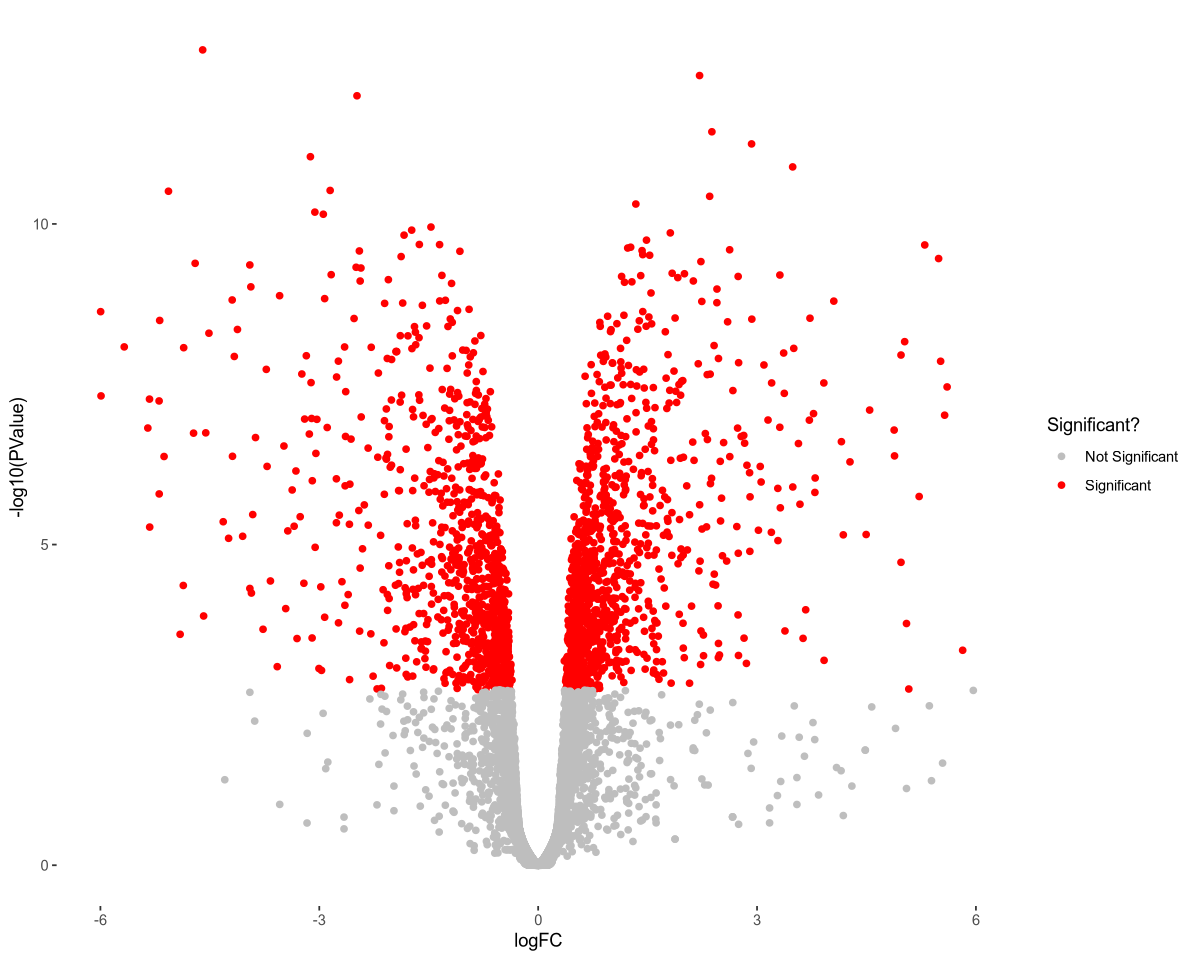

In [64]:
## plot volcano for fusion
fixed_volcano <- logfc_fixed %>%
    ggplot(aes(x = logFC, y = -log10(PValue), color = significance)) +
        geom_point() +
        labs(color = "Significant?") +
        scale_color_manual(values = c("gray", "red")) +
        xlim(-6, 6) +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA))
fixed_volcano

In [65]:
## add location information to logfc data
logfc_fixed_chr <- gtf_genes %>%
    full_join(logfc_fixed, by = "gene") %>%
    mutate(significance = case_when(is.na(significance) ~ "Not Significant",
                                    TRUE ~ significance)) %>%
    na.omit()

## determine if there is an enrichment for differentially expressed genes on the fourth chromosome
fourth_diff <- logfc_fixed_chr %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, significance) %>%
    count() %>%
    pivot_wider(names_from = significance, values_from = n) %>%
    mutate(across(is.numeric, replace_na, replace = 0)) %>%
    column_to_rownames("fourth")
chisq.test(fourth_diff)$p.value

## determine if there is an enrichment for genes with decreased expression on the fourth chromosome
fourth_low <- logfc_fixed_chr %>%
    mutate(direction = case_when(logFC > 0 & significance == "Significant" ~ "decrease",
                                 TRUE ~ "other")) %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, direction) %>%
    count() %>%
    pivot_wider(names_from = direction, values_from = n) %>%
    mutate(across(is.numeric, replace_na, replace = 0)) %>%
    column_to_rownames("fourth")
chisq.test(fourth_low)$p.value

## determine if there is an enrichment for genes with decreased expression on the fourth chromosome
fourth_low <- logfc_fixed_chr %>%
    mutate(direction = case_when(logFC < 0 & significance == "Significant" ~ "decrease",
                                 TRUE ~ "other")) %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, direction) %>%
    count() %>%
    pivot_wider(names_from = direction, values_from = n) %>%
    mutate(across(is.numeric, replace_na, replace = 0)) %>%
    column_to_rownames("fourth")
chisq.test(fourth_low)$p.value

[1] 0.05464066

[1] 2.346104e-05

[1] 0.06535945

In [66]:
logfc_fixed_chr %>%
    mutate(direction = case_when(logFC < 0 & significance == "Significant" ~ "decrease",
                                 TRUE ~ "other")) %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, direction) %>%
    count() %>%
    pivot_wider(names_from = direction, values_from = n)

fourth,decrease,other
<chr>,<int>,<int>
fourth,190,1879
other,648,7543


Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_point()`).”


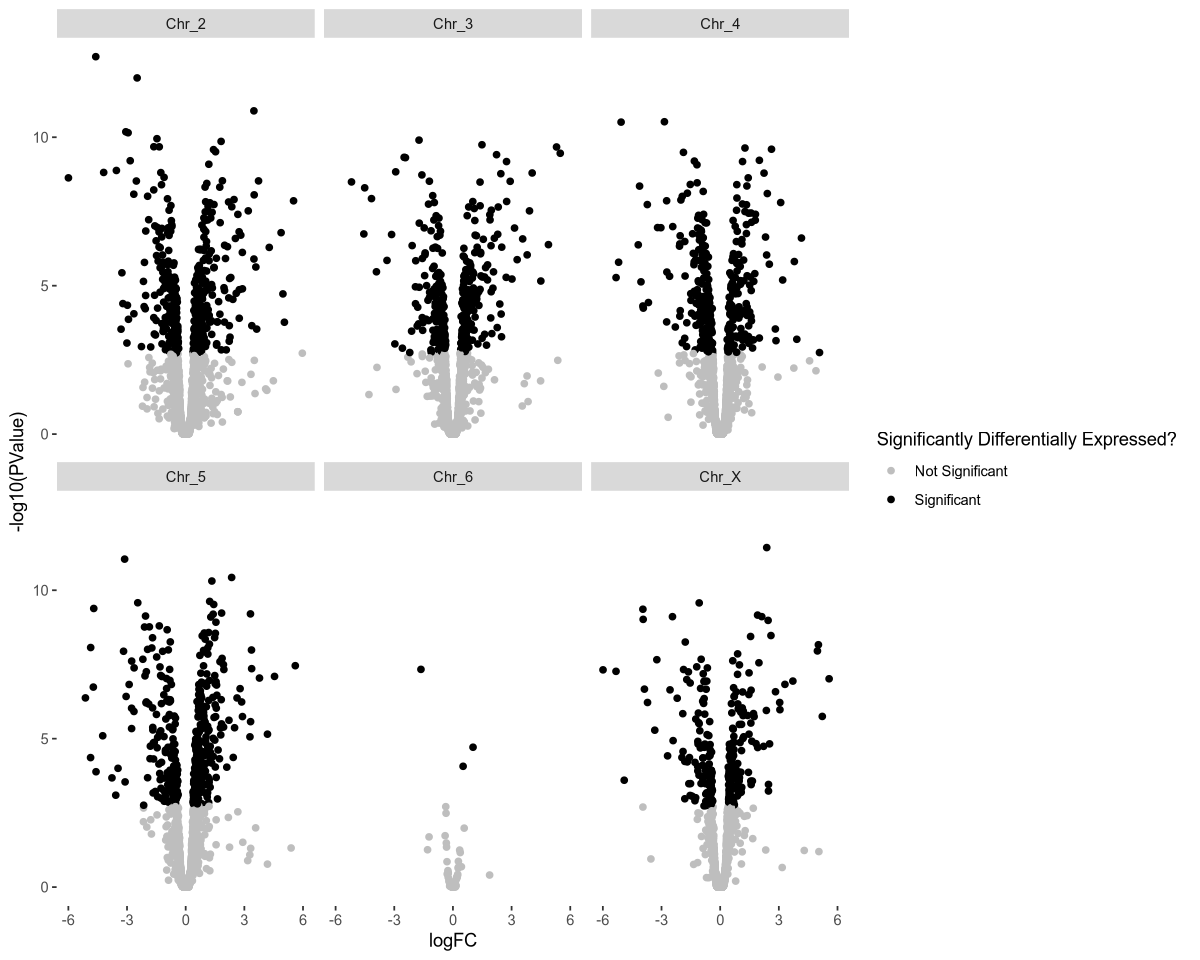

In [67]:
## plot volcano for fusion
fixed_chr_volcano <- logfc_fixed_chr %>%
    mutate(chr = case_when(significance == "Significant" ~ str_replace_all(chromosome, "Chr_", "Chromosome "),
                           TRUE ~ "Not Significant")) %>%
    ggplot(aes(x = logFC, y = -log10(PValue), color = significance)) +
        geom_point() +
        labs(color = "Significantly Differentially Expressed?") +
        xlim(-6, 6) +
        scale_color_manual(values = c("gray", "black")) +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA)) +
        facet_wrap(~chromosome)
fixed_chr_volcano

In [68]:
## save plot
ggsave("figures/sb_alignment/fixed_chr_volcano.png", fixed_chr_volcano)

Saving 7 x 7 in image


Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_point()`).”


### Try to increase signal by only including localities with close to fix rates that match fusion status

In [69]:
## identify fixed localities
fixed_locations <- c("PG", "SI", "SB", "IR", "DI", "HI", "CF", "CI", "RB", "CB", "FP")

## determine which fixed localities have the corresponding fusion status in our strains
fixed_test <- sample_info %>% 
    filter(grepl("fuse", status, ignore.case = TRUE)) %>%
    filter(locality %in% fixed_locations)
## PG, HI, and IR in the north and RB and FP in the south

## filter for properly fixed locations
fixed <- c("PG", "IR", "HI", "RB", "FP")
trunc_sample_info <- sample_info %>% 
    filter(grepl("fuse", status, ignore.case = TRUE)) %>%
    filter(locality %in% fixed)

In [70]:
# ## calculate logfc based on fusion status for populations

## create empty logfc table to add the future log fold change data to
logfc_fixed <- data.frame(gene = normalized_reads$gene) %>%
    rownames_to_column("number")

## truncate all of the data to only include populations with fusion information
trunc_cm <- normalized_reads %>%
    select(any_of(trunc_sample_info$sample))
trunc_groups <- trunc_sample_info$status
trunc_design <- model.matrix(~ trunc_groups)

## run differential gene expression
trunc_dgeList <- DGEList(counts = trunc_cm, group = trunc_groups)
trunc_dgeList <- calcNormFactors(trunc_dgeList)
trunc_dgeList <- estimateDisp(trunc_dgeList, trunc_design)
trunc_dgeList_fit <- glmQLFit(trunc_dgeList, trunc_design, robust = TRUE)

trunc_dge <- glmTreat(trunc_dgeList_fit, coef = 2)
trunc_dge_tags <- topTags(trunc_dge, n = NULL)

## get logfc and statistical information
logfc_nearfixed <- trunc_dge_tags$table %>%
    rownames_to_column("number") %>%
    full_join(logfc_fixed, by = "number") %>%
    select(-number) %>%
    select(gene, logFC, PValue, FDR) %>%
    mutate(significance = case_when(PValue < 0.05 & FDR < 0.01 ~ "Significant",
                                    TRUE ~ "Not Significant"))

Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.obs = lib.size[i], :
“NaNs produced”
Warning message in .calcFactorTMM(obs = x[, i], ref = x[, refColumn], libsize.ob

In [71]:
## count how many significant and unsignificant genes
logfc_nearfixed %>%
    group_by(significance) %>%
    count()

significance,n
<chr>,<int>
Not Significant,10568
Significant,57


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


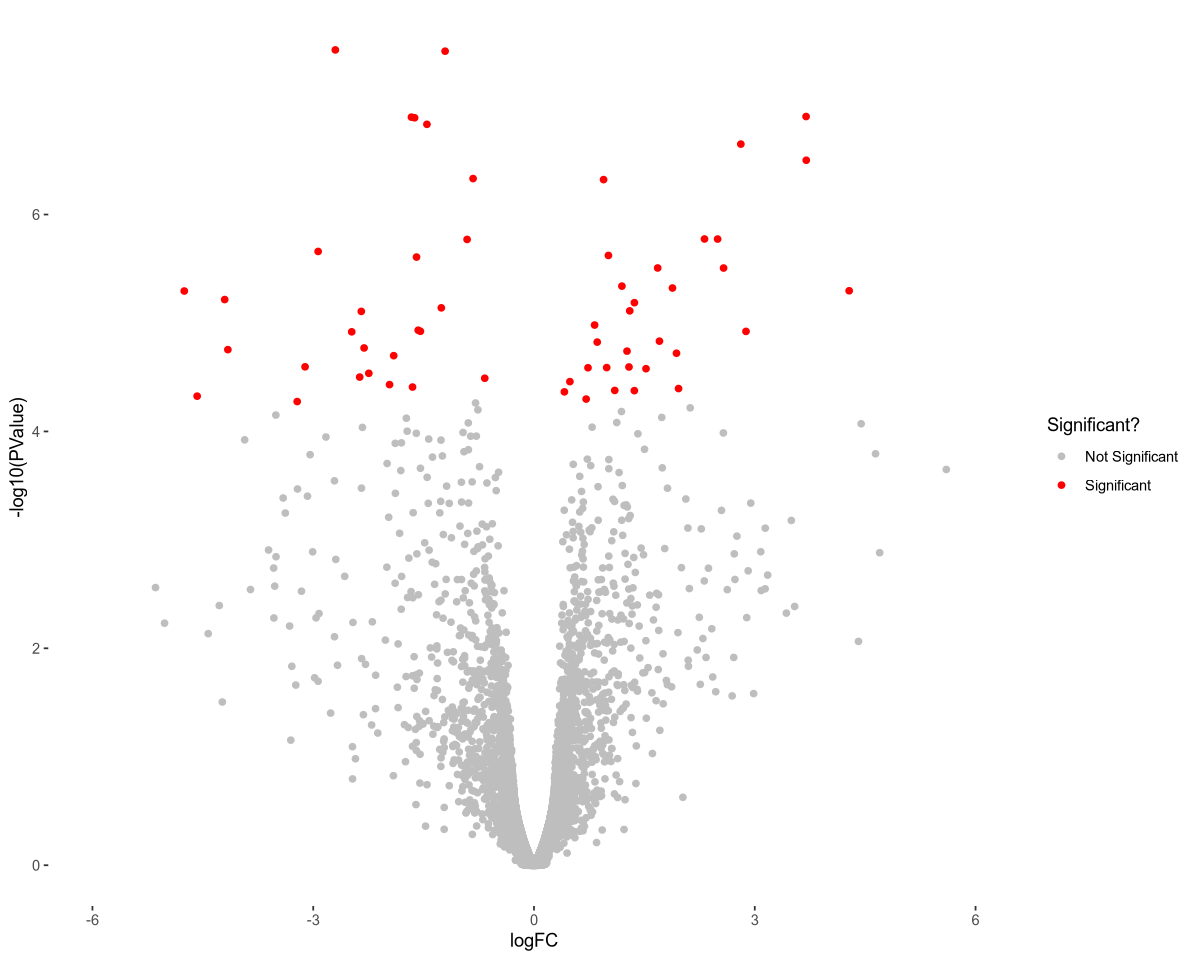

In [80]:
## plot volcano for fusion
nearfixed_volcano <- logfc_nearfixed %>%
    ggplot(aes(x = logFC, y = -log10(PValue), color = significance)) +
        geom_point() +
        labs(color = "Significant?") +
        scale_color_manual(values = c("gray", "red")) +
        xlim(-6, 6) +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA))
nearfixed_volcano

In [81]:
## add location information to logfc data
logfc_nearfixed_chr <- gtf_genes %>%
    full_join(logfc_nearfixed, by = "gene") %>%
    mutate(significance = case_when(is.na(significance) ~ "Not Significant",
                                    TRUE ~ significance)) %>%
    na.omit()

## determine if there is an enrichment for differentially expressed genes on the fourth chromosome
fourth_diff <- logfc_nearfixed_chr %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, significance) %>%
    count() %>%
    pivot_wider(names_from = significance, values_from = n) %>%
    mutate(across(is.numeric, replace_na, replace = 0)) %>%
    column_to_rownames("fourth")
fisher.test(fourth_diff)$p.value

## determine if there is an enrichment for genes with decreased expression on the fourth chromosome
fourth_low <- logfc_nearfixed_chr %>%
    mutate(direction = case_when(logFC > 0 & significance == "Significant" ~ "decrease",
                                 TRUE ~ "other")) %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, direction) %>%
    count() %>%
    pivot_wider(names_from = direction, values_from = n) %>%
    mutate(across(is.numeric, replace_na, replace = 0)) %>%
    column_to_rownames("fourth")
fisher.test(fourth_low)$p.value

## determine if there is an enrichment for genes with decreased expression on the fourth chromosome
fourth_low <- logfc_nearfixed_chr %>%
    mutate(direction = case_when(logFC < 0 & significance == "Significant" ~ "decrease",
                                 TRUE ~ "other")) %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, direction) %>%
    count() %>%
    pivot_wider(names_from = direction, values_from = n) %>%
    mutate(across(is.numeric, replace_na, replace = 0)) %>%
    column_to_rownames("fourth")
fisher.test(fourth_low)$p.value

[1] 0.06322192

[1] 0.01994659

[1] 1

In [82]:
logfc_nearfixed_chr %>%
    mutate(direction = case_when(logFC < 0 & significance == "Significant" ~ "decrease",
                                 TRUE ~ "other")) %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, direction) %>%
    count() %>%
    pivot_wider(names_from = direction, values_from = n)

fourth,decrease,other
<chr>,<int>,<int>
fourth,3,2066
other,13,8178


In [83]:
logfc_nearfixed_chr %>%
    filter(logFC < 0 & significance == "Significant" & chromosome == "Chr_4")

chromosome,gene,logFC,PValue,FDR,significance
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
Chr_4,ninaC,-2.3685474,3.154588e-05,0.007286413,Significant
Chr_4,LOC6628526,-4.7520688,5.072827e-06,0.002449945,Significant
Chr_4,LOC6633921,-0.9089758,1.696910e-06,0.001386898,Significant


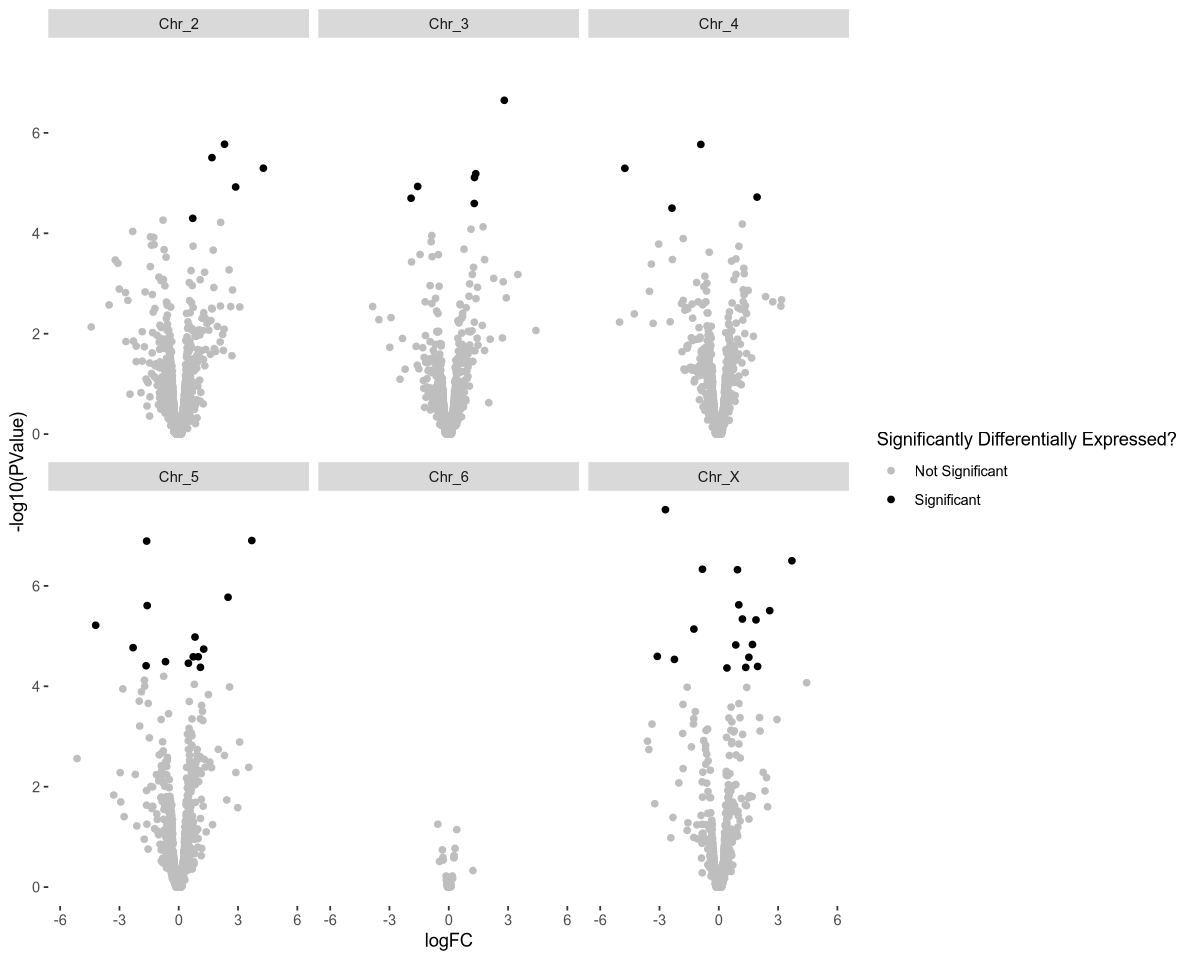

In [86]:
## plot volcano for fusion
nearfixed_chr_volcano <- logfc_nearfixed_chr %>%
    mutate(chr = case_when(significance == "Significant" ~ str_replace_all(chromosome, "Chr_", "Chromosome "),
                           TRUE ~ "Not Significant")) %>%
    ggplot(aes(x = logFC, y = -log10(PValue), color = significance)) +
        geom_point() +
        labs(color = "Significantly Differentially Expressed?") +
        xlim(-6, 6) +
        scale_color_manual(values = c("gray", "black")) +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA)) +
        facet_wrap(~chromosome)
nearfixed_chr_volcano

In [87]:
## save plot
ggsave("figures/sb_alignment/nearfixed_chr_volcano.png", nearfixed_chr_volcano)

Saving 7 x 7 in image


### Find genes whose expression correlate with latitude

In [88]:
# ## get the list of genes to iterate through
# genes <- unique(lat_expression$gene)

# ## create empty data frame to populate
# lmm_df <- matrix(data = NA, nrow = length(genes), ncol = 3,
#                  dimnames = list(genes, c("estimate", "pvalue", "std_err"))) %>%
#   as.data.frame()
  
# ## populate data with correlation information
# for (i in genes) {
  
#   ## filter data frame for only gene of interest
#   lat_expression_gene <- lat_expression %>%
#     filter(gene == i)
  
#   ## calculate correlation between gene expression and latitude and save output
#   lmm_result <- summary(lmer(count ~ latitude + (1| locality / strain), data = lat_expression_gene))
#   estimate <- lmm_result$coefficients["latitude","Estimate"]
#   pvalue <- lmm_result$coefficients["latitude","Pr(>|t|)"]
#   std_err <- lmm_result$coefficients["latitude","Std. Error"]
  
#   ## store output in data frame
#   lmm_df[[i, "estimate"]] <- estimate
#   lmm_df[[i, "pvalue"]] <- pvalue
#   lmm_df[[i, "std_err"]] <- std_err
  
# }

# ## add rownames as a column
# lmm_df <- lmm_df %>%
#   rownames_to_column("gene")

# ## correct pvalue for false discovery rate
# lmm_df$pvalue_corrected <- p.adjust(lmm_df$pvalue, method = "BH")

# write_tsv(lmm_df, "lat-ge_lmm.tsv")

In [89]:
## load in correlation data frame
lmm_df <- read_tsv("intermediate/lat-ge_lmm.tsv")
head(lmm_df)

Rows: 10625 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): gene
dbl (4): estimate, pvalue, std_err, pvalue_corrected

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


gene,estimate,pvalue,std_err,pvalue_corrected
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
cdi,-106.3728403,0.08178567,59.067602,0.4510192
mRpL55,0.3468941,0.88058541,2.283499,0.9648740
ATPsynD,5.3204653,0.77717534,18.598461,0.9259074
sav,3.0304692,0.64915932,6.581749,0.8781921
Ctns,2.5131739,0.74916087,7.787954,0.9143206
p53,-2.0768906,0.21432128,1.637068,0.6074421


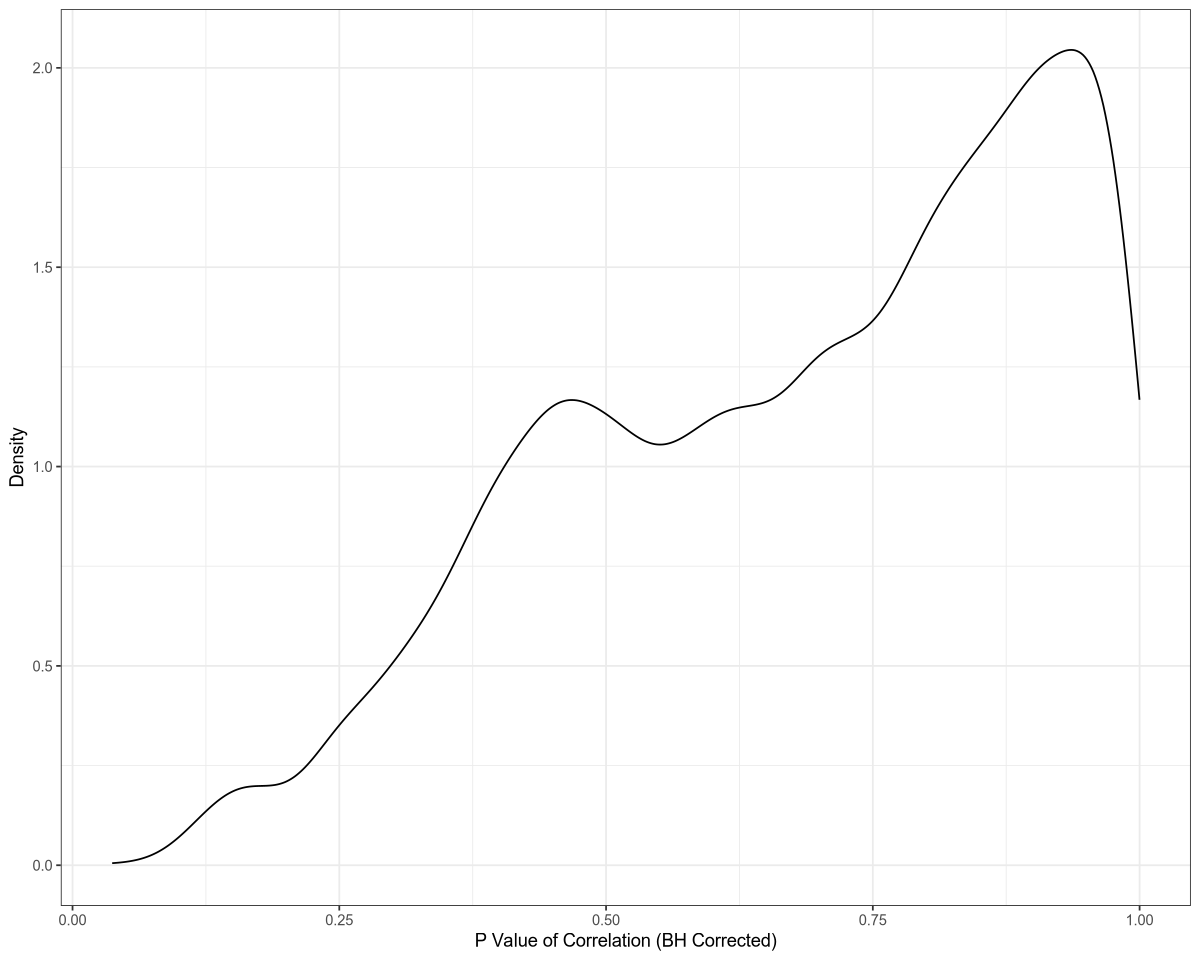

In [90]:
## plot the density of genes with significant correlations to latitude
lmm_density <- lmm_df %>%
    ggplot(aes(x = pvalue_corrected)) +
        geom_density() +
        labs(x = "P Value of Correlation (BH Corrected)", y = "Density") +
        theme_bw()
lmm_density

Warning message:
“Removed 10623 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


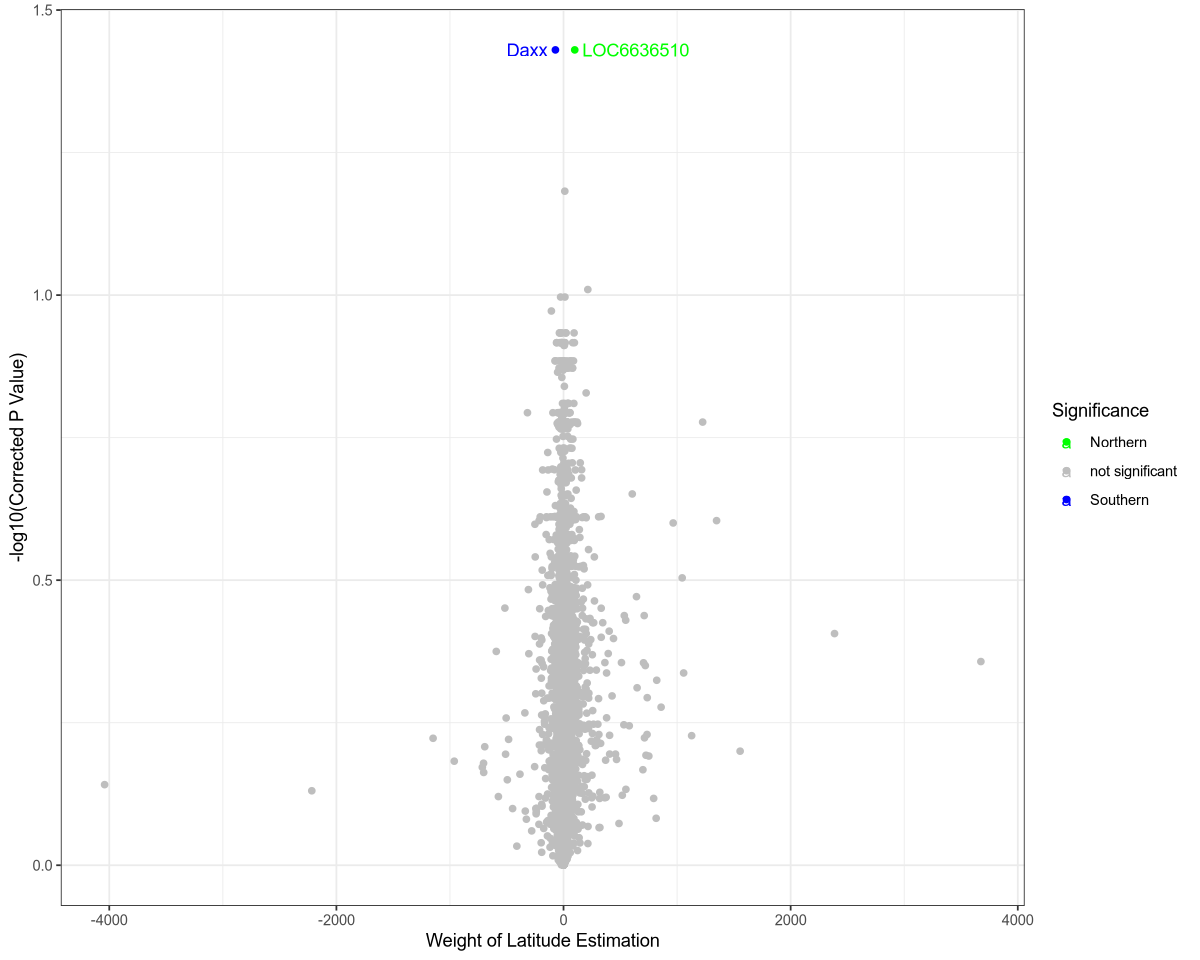

In [91]:
## annotate genes based on their correlations
lmm_genes_annotated <- lmm_df %>%
    mutate(significance = case_when(pvalue_corrected < 0.05 ~ "Significant",
                                    TRUE ~ "Not Significant"),
           lat_cor = case_when(pvalue_corrected < 0.05 & estimate > 0 ~ "Northern",
                               pvalue_corrected < 0.05 & estimate < 0 ~ "Southern",
                               TRUE ~ "not significant"),
           label = case_when(pvalue_corrected < 0.05 ~ gene,
                             TRUE ~ NA))

## make a pseudo volcano plot
lmm_genes_volcano <- lmm_genes_annotated %>%
    ggplot(aes(x = estimate, y = -log10(pvalue_corrected), color = lat_cor)) +
        geom_point(aes(x = estimate, y = -log10(pvalue_corrected), color = lat_cor)) +
        geom_text_repel(aes(label = label)) +
        labs(x = "Weight of Latitude Estimation", y = "-log10(Corrected P Value)",
             color = "Significance") +
        scale_color_manual(values = c("Green", "Gray", "Blue")) +
        theme_bw()
lmm_genes_volcano

In [92]:
## save plot
ggsave("figures/sb_alignment/sb_reads_lmm_lat.png", lmm_genes_volcano)

Saving 7 x 7 in image
Warning message:
“Removed 10623 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


In [93]:
gtf_genes %>%
    filter(gene == "Daxx" | grepl("LOC663651", gene))

chromosome,gene
<chr>,<chr>
Chr_4,Daxx
Chr_5,LOC6636512
Chr_5,LOC6636511


In [94]:
# ## scale gene expression per samples
# lat_scaled <- reads %>%
#   column_to_rownames("gene") %>%
#   scale() %>%
#   as.data.frame() %>%
#   rownames_to_column("gene") %>%
#   pivot_longer(!gene, names_to = "sample", values_to = "count") %>%
#   separate_wider_delim(sample, delim = "_", names = c("locality", "female", "number", "replicate"), too_few = "align_start", cols_remove = FALSE) %>%
#   mutate(strain = paste(locality, female, number, sep = "_")) %>%
#   left_join(local_lat, by = "locality") %>%
#   na.omit()


# ## create empty data frame to populate
# lmm_df <- matrix(data = NA, nrow = length(genes), ncol = 3,
#                  dimnames = list(genes, c("estimate", "pvalue", "std_err"))) %>%
#   as.data.frame()

# ## populate data with correlation information
# for (i in genes) {
  
#   ## filter data frame for only gene of interest
#   lat_scaled_gene <- lat_scaled %>%
#     filter(gene == i)
  
#   ## calculate correlation between gene expression and latitude and save output
#   lmm_result <- summary(lmer(count ~ latitude + (1| locality / strain), data = lat_scaled_gene))
#   estimate <- lmm_result$coefficients["latitude","Estimate"]
#   pvalue <- lmm_result$coefficients["latitude","Pr(>|t|)"]
#   std_err <- lmm_result$coefficients["latitude","Std. Error"]
  
#   ## store output in data frame
#   lmm_df[[i, "estimate"]] <- estimate
#   lmm_df[[i, "pvalue"]] <- pvalue
#   lmm_df[[i, "std_err"]] <- std_err
  
# }

# ## add rownames as a column
# lmm_df <- lmm_df %>%
#   rownames_to_column("gene")

# ## correct pvalue for false discovery rate
# lmm_df$pvalue_corrected <- p.adjust(lmm_df$pvalue, method = "BH")

# write_tsv(lmm_df, "intermediate/lat-ge_lmm_scaled.tsv")

In [95]:
## load in scaled lmm
lmm_scaled <- read_tsv("intermediate/lat-ge_lmm_scaled.tsv")
head(lmm_scaled)

Rows: 10625 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): gene
dbl (4): estimate, pvalue, std_err, pvalue_corrected

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


gene,estimate,pvalue,std_err,pvalue_corrected
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
cdi,-7.944811e-03,0.05915236,0.0040502299,0.6852992
mRpL55,6.946695e-05,0.87572660,0.0004404151,0.9997498
ATPsynD,1.804576e-04,0.89178083,0.0013129796,0.9997498
sav,1.296146e-04,0.79886753,0.0005034255,0.9997498
Ctns,2.301651e-04,0.77004102,0.0007802740,0.9997498
p53,-1.145019e-04,0.81956774,0.0004696081,0.9997498


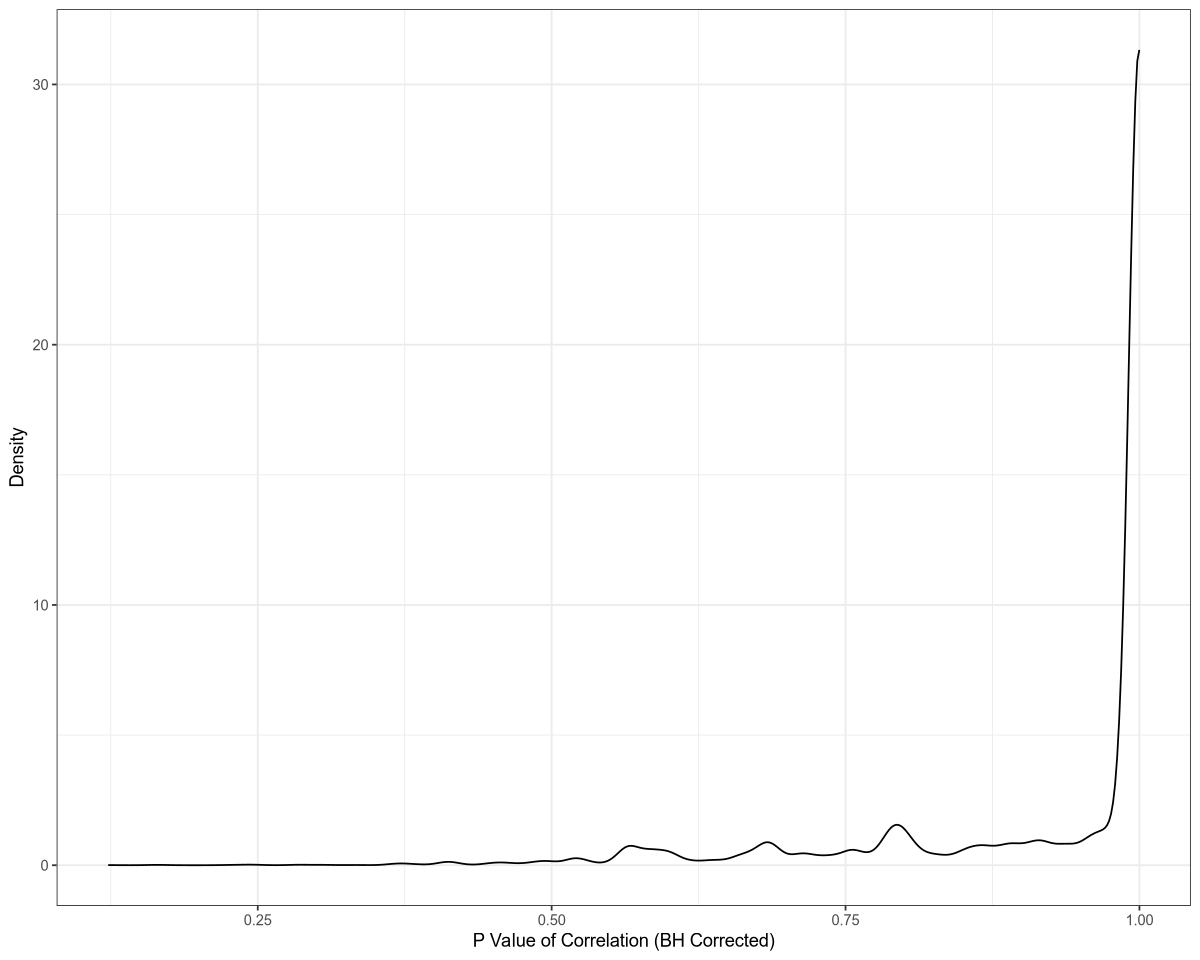

In [96]:
## plot the density of genes with significant correlations to latitude
lmm_density <- lmm_scaled %>%
    ggplot(aes(x = pvalue_corrected)) +
        geom_density() +
        labs(x = "P Value of Correlation (BH Corrected)", y = "Density") +
        theme_bw()
lmm_density

Warning message:
“Removed 10625 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


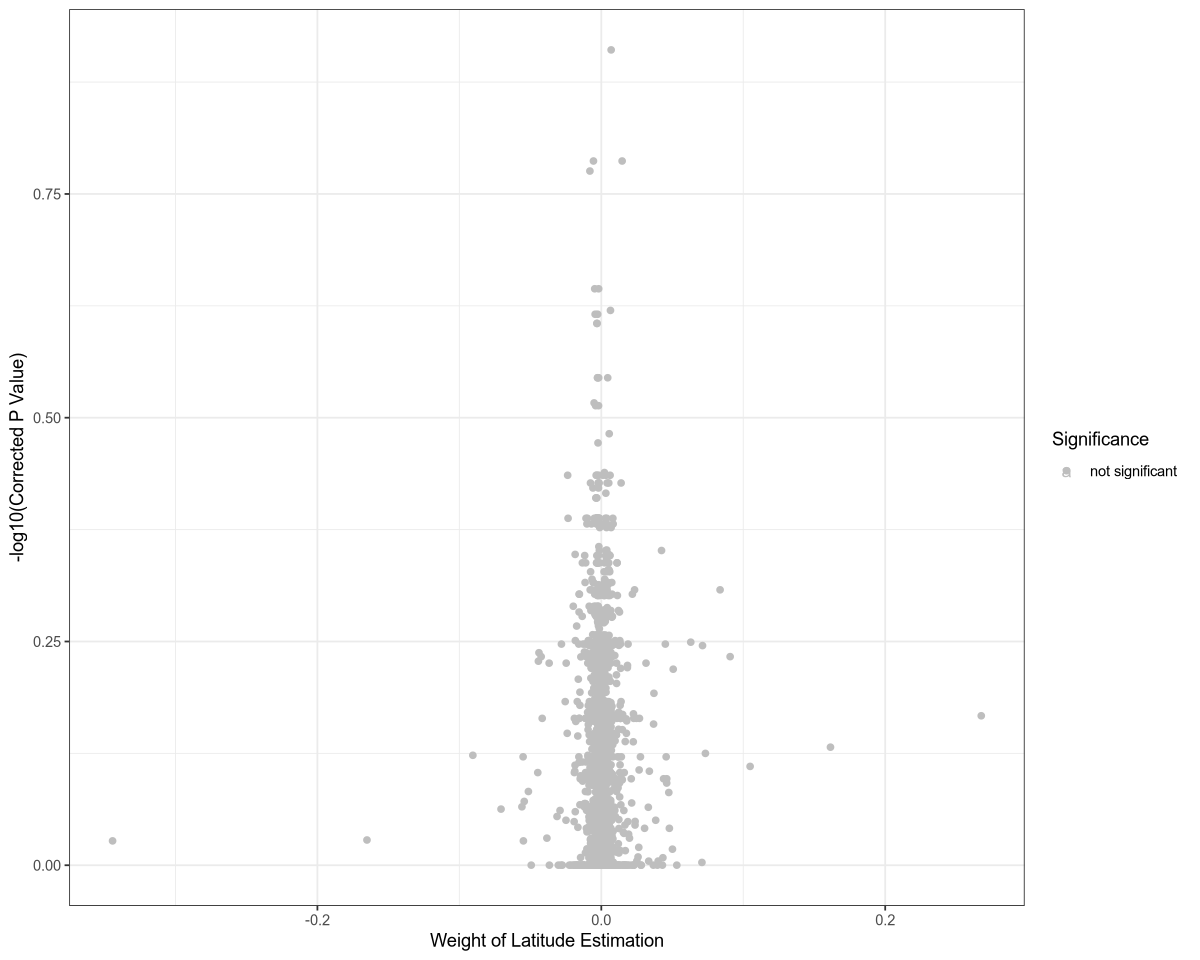

In [97]:
## annotate genes based on their correlations
lmm_genes_annotated <- lmm_scaled %>%
    mutate(significance = case_when(pvalue_corrected < 0.05 ~ "Significant",
                                    TRUE ~ "Not Significant"),
           lat_cor = case_when(pvalue_corrected < 0.05 & estimate > 0 ~ "Northern",
                               pvalue_corrected < 0.05 & estimate < 0 ~ "Southern",
                               TRUE ~ "not significant"),
           label = case_when(pvalue_corrected < 0.05 ~ gene,
                             TRUE ~ NA))

## make a pseudo volcano plot
lmm_genes_volcano <- lmm_genes_annotated %>%
    ggplot(aes(x = estimate, y = -log10(pvalue_corrected), color = lat_cor)) +
        geom_point(aes(x = estimate, y = -log10(pvalue_corrected), color = lat_cor)) +
        geom_text_repel(aes(label = label)) +
        labs(x = "Weight of Latitude Estimation", y = "-log10(Corrected P Value)",
             color = "Significance") +
        scale_color_manual(values = c("Gray")) +
        theme_bw()
lmm_genes_volcano